# Product-Store Sales Prediction for DSN Mart

## Business Understanding

### Introduction

Accurate sales prediction is important in retail because it can help businesses make better decisions about inventory, pricing, and resource allocation. In this project, I will be working with historical sales records from DSN Mart, a retail chain with stores across different locations and store formats in Nigeria.

My aim is to understand the factors that may influence product-level sales across different stores and use these insights to build a machine learning model that can predict the total sales of a given product at a given store.

### Business Objective

The main objective of this project is to develop a robust and accurate machine learning model that predicts total sales for a given product at a given store, using the available information about the product and the outlet where it is sold.

I aim to use the predictions to understand differences in sales performance across products, stores, and locations, while exploring how the available product and store characteristics relate to sales.

### Business Goals

The goals of this project are to:

- Understand the factors that may influence product-store sales.
- Analyse sales patterns across different products, store formats, and locations.
- Develop and evaluate machine learning models for predicting total sales.
- Engineer relevant features that can improve model performance.
- Generate predictions for unseen product-store records.
- Use the results to provide insights that can support better retail decision-making.

## Data Understanding

### Data Collection

The data for this project was obtained from Kaggle, as part of the DSN Bootcamp Qualification Hackathon 2026 (ML Track). The competition provided two CSV files, train.csv and test.csv, made available via the competition's Data page on Kaggle.

### Data Description

The training data consists of product-store level records, combining product attributes (such as weight, category, price, fat content, and shelf visibility) with store attributes (such as age, size, location tier, and format), alongside the target variable, total_sales. The test data contains the same features as the training data, with total_sales removed(this is the value to be predicted).

### File Descriptions and Data Field Information

#### train.csv
The training data, comprising product-store records with the following features and the target total_sales:

- id — Unique identifier for each row.
- product_code — Unique code identifying the product.
- product_weight_kg — Weight of the product in kilograms (contains missing values).
- fat_content — Whether the product is labeled "Low Fat" or "Regular."
- shelf_visibility — Proportion of total display area in the store allocated to this product.
- product_category — The product's category (capitalization is inconsistent across entries, reflecting real-world data quality).
- product_price — The product's listed price.
- store_code — Unique identifier for the store.
- store_age_years — Number of years the store has been operating.
- store_size — Store size category: Small, Medium, or Large (contains missing values).
- store_location_tier — Tier of the store's location: Tier_1 (major urban centers), Tier_2 (state capitals), Tier_3 (smaller towns).
- store_format — Store format: Corner Shop, Standard Supermarket, Superstore, or Flagship Hypermarket.
- total_sales — Target. Total sales value for this product at this store.

#### test.csv
The test data, containing the same features as train.csv, excluding total_sales. Predictions of total_sales are required for each row in this file.

#### sample_submission.csv
A sample submission file showing the correct format expected for the leaderboard.

Data Quality Observations

Initial inspection of the data highlights a few issues that will need to be addressed during data preparation:

Missing values in product_weight_kg and store_size, requiring an appropriate imputation strategy.
Inconsistent capitalization in product_category, requiring normalization before the feature can be reliably encoded or grouped.

### Libraries importation

In [1]:
#libraries for handling data
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)

##data visualizations
from scipy import stats
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

##Error evaluations
from sklearn.metrics import mean_squared_error, mean_squared_log_error, mean_squared_log_error
from scipy.stats import boxcox

## Algorithms
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

#Feature processing libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
#from category_encoders.binary import BinaryEncoder
from sklearn.preprocessing import OrdinalEncoder

## Additional libraries used later in the notebook
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna

### Data Loading

In [2]:
# loading the data
train = pd.read_csv(r"C:\Users\GCT\Documents\Aliyyah\DSN Project\train.csv")
test = pd.read_csv(r"C:\Users\GCT\Documents\Aliyyah\DSN Project\test.csv")

In [3]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


## Exploratory Data Analysis
- We will explore each dataset individually
- We will answer each questions
- A heavy focus will be on the train dataset since that's the most crucial dataset for our predictions

### Understanding the training data

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.2 MB


In [6]:
# Checking for null values
train.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [7]:
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [8]:
# Investigate all the main elements with each features of the train data

for column in train:
    unique_vals = np.unique(train[column].dropna())
    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature id :6818
The number of values for feature product_code :1555
The number of values for feature product_weight_kg :4675
The number of values for feature fat_content :2 -- ['Low Fat' 'Regular']
The number of values for feature shelf_visibility :1732
The number of values for feature product_category :48
The number of values for feature product_price :5818
The number of values for feature store_code :10 -- ['STORE-7WS' 'STORE-89Z' 'STORE-9RG' 'STORE-AGY' 'STORE-DKU' 'STORE-HL7'
 'STORE-JOR' 'STORE-OYG' 'STORE-T5G' 'STORE-YLW']
The number of values for feature store_age_years :9 -- [23 25 28 30 33 34 35 45 47]
The number of values for feature store_size :3 -- ['Large' 'Medium' 'Small']
The number of values for feature store_location_tier :3 -- ['Tier_1' 'Tier_2' 'Tier_3']
The number of values for feature store_format :4 -- ['Corner Shop' 'Flagship Hypermarket' 'Standard Supermarket' 'Superstore']
The number of values for feature total_sales :6776


### EDA Summary

From .info(), I confirmed the datatypes were all in the correct form for each feature. There were missing values in 2 columns; one categorical (store_size) and one numerical (product_weight_kg); about 18% and 28% of data missing respectively. Since these missing values could still carry useful information for predicting sales, I chose not to drop either column.

.describe() showed that most numerical features had moderate/low variability, with mean and median close together; except shelf_visibility and total_sales, which were right-skewed, with the mean noticeably higher than the median in both cases.

Checking the number of unique values in each column, product_category stood out with 48 unique values; higher than expected, confirming the data inconsistency issue (inconsistent capitalization) that needs to be cleaned before encoding. Other categorical columns (fat_content, store_size, store_location_tier, store_format) had clean, low-cardinality values.

For product_weight_kg, since .describe() showed its variability was not very high (mean close to median, moderate std), I'll use the median as the imputation method. For store_size, being categorical, I'll use the mode or consider treating missing values as their own category if the missingness turns out to be non-random.

In [9]:
#fixing the inconsistencies in the product category

train['product_category'] = train['product_category'].str.title()
print('The number of values for feature product_category is', train['product_category'].nunique())
train['product_category'].unique()

The number of values for feature product_category is 16


<ArrowStringArray>
[         'Frozen Foods',    'Health And Hygiene',                'Canned',
           'Soft Drinks',                  'Meat',           'Snack Foods',
          'Baking Goods',             'Household',                 'Dairy',
 'Fruits And Vegetables',             'Breakfast',                'Breads',
               'Seafood',                'Others',           'Hard Drinks',
         'Starchy Foods']
Length: 16, dtype: str

In [10]:
# #handling missing values in the product_weight_kg by imputing missing product_weight_kg with the median

# median_kg = train['product_weight_kg'].median()

# train['product_weight_kg'] = train['product_weight_kg'].fillna(median_kg)
# print("Number of missing values in product_weight is", train['product_weight_kg'].isnull().sum())

# Handling missing values in product_weight_kg by imputing with category-level median
category_median_kg = train.groupby('product_category')['product_weight_kg'].transform('median')

train['product_weight_kg'] = train['product_weight_kg'].fillna(category_median_kg)

print("Number of missing values in product_weight_kg is", train['product_weight_kg'].isnull().sum())

Number of missing values in product_weight_kg is 0


In [11]:
# Checking if the missing value for the store_size is random to know how to best handle it. 
train['store_size_missing'] = train['store_size'].isnull()

# Checking if missingness is related to store_format
train.groupby('store_format')['store_size_missing'].mean()

store_format
Corner Shop             0.506928
Flagship Hypermarket    0.000000
Standard Supermarket    0.331690
Superstore              0.000000
Name: store_size_missing, dtype: float64

In [12]:
# Checking if missingness is related to store_location_tier
train.groupby('store_location_tier')['store_size_missing'].mean()

store_location_tier
Tier_1    0.000000
Tier_2    0.663082
Tier_3    0.163990
Name: store_size_missing, dtype: float64

In [13]:
# Checking if missingness is related to store_code (individual stores)
train.groupby('store_code')['store_size_missing'].mean()

store_code
STORE-7WS    0.0
STORE-89Z    0.0
STORE-9RG    0.0
STORE-AGY    0.0
STORE-DKU    1.0
STORE-HL7    0.0
STORE-JOR    1.0
STORE-OYG    1.0
STORE-T5G    0.0
STORE-YLW    0.0
Name: store_size_missing, dtype: float64

In [14]:
train.groupby('store_format')['store_size'].value_counts(normalize=True)*100

store_format          store_size
Corner Shop           Small         100.000000
Flagship Hypermarket  Medium        100.000000
Standard Supermarket  Small          50.503018
                      Large          25.083836
                      Medium         24.413146
Superstore            Medium        100.000000
Name: proportion, dtype: float64

### Observation how to handle the store_size missing value

The store_code check made it clear that 3 stores had store_size missing for 100% of their rows, while the other 7 had none missing so the missingness is tied to specific stores and not random.

To decide how to fill it in, I checked if store_format predicts store_size. It does for most formats like the Corner Shop, Flagship Hypermarket, and Superstore are each 100% a single size. Standard Supermarket is mixed, with no clear dominant size.

So I'll impute missing Corner Shop rows as "Small", and explore Standard Supermarket more and see if there is any pattern I can use to impute that

In [15]:
# Filling the missing store_size for Corner Shop rows with "Small"
corner_shops = (train['store_format'] == 'Corner Shop') & (train['store_size'].isnull())
train.loc[corner_shops, 'store_size'] = 'Small'

In [16]:
print("Number of missing values in store_size is", train['store_size'].isnull().sum())

Number of missing values in store_size is 1480


In [17]:
print("Total missing:", train['store_size'].isnull().sum())
print(train[train['store_size'].isnull()]['store_code'].value_counts())

Total missing: 1480
store_code
STORE-OYG    744
STORE-DKU    736
Name: count, dtype: int64


#### Now exploring if there is any other way other features can tell me how to impute my remaining missing values

We can see now that the corner shop changes reflected on the store-jor so now howdo we handle the remaining two stores thta their store format is a standard supermarket.

In [18]:
train[train['store_format'] == 'Standard Supermarket'].groupby('store_location_tier')['store_size'].value_counts(normalize=True)

store_location_tier  store_size
Tier_1               Small         0.508772
                     Medium        0.491228
Tier_2               Small         1.000000
Tier_3               Large         1.000000
Name: proportion, dtype: float64

In [19]:
train[train['store_code'].isin(['STORE-DKU', 'STORE-OYG'])][['store_code', 'store_format', 'store_location_tier', 'store_age_years']].drop_duplicates()

,store_code,store_format,store_location_tier,store_age_years
11,STORE-OYG,Standard Supermarket,Tier_2,25
14,STORE-DKU,Standard Supermarket,Tier_2,30


This is huge. We can see that both standard supermarket stores have tier 2 as their lication tier and now I have confidently seen that from the data, every standard supermarket that has tier 2 as the store location is small so now we can go ahead and impute small for that.

In [20]:
stores_remaining = (train['store_code'].isin(['STORE-DKU', 'STORE-OYG'])) & (train['store_size'].isnull())
train.loc[stores_remaining, 'store_size'] = 'Small'
print("Number of missing values in store_size is", train['store_size'].isnull().sum())

Number of missing values in store_size is 0


In [21]:
# Checking for null values
train.isnull().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
store_size_missing     0
dtype: int64

In [22]:
# checking for duplicates
train.duplicated().sum()

np.int64(0)

### Now let us adjust our test data as well


In [23]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1705 non-null   str    
 1   product_code         1705 non-null   str    
 2   product_weight_kg    1399 non-null   float64
 3   fat_content          1705 non-null   str    
 4   shelf_visibility     1705 non-null   float64
 5   product_category     1705 non-null   str    
 6   product_price        1705 non-null   float64
 7   store_code           1705 non-null   str    
 8   store_age_years      1705 non-null   int64  
 9   store_size           1214 non-null   str    
 10  store_location_tier  1705 non-null   str    
 11  store_format         1705 non-null   str    
dtypes: float64(3), int64(1), str(8)
memory usage: 283.4 KB


In [24]:
test.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years
count,1399.000000,1705.000000,1705.000000,1705.000000
mean,12.865960,0.068491,143.069490,34.127859
std,4.647713,0.051721,61.888692,8.322650
min,4.693000,0.000000,31.980000,23.000000
25%,8.753000,0.030200,96.560000,28.000000
50%,12.617000,0.056400,144.630000,33.000000
75%,16.915500,0.098400,185.210000,45.000000
max,21.980000,0.302000,270.870000,47.000000


In [25]:
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [26]:
# Investigate all the main elements with each features of the train data

for column in test:
    unique_vals = np.unique(test[column].dropna())
    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature id :1705
The number of values for feature product_code :1082
The number of values for feature product_weight_kg :1329
The number of values for feature fat_content :2 -- ['Low Fat' 'Regular']
The number of values for feature shelf_visibility :984
The number of values for feature product_category :48
The number of values for feature product_price :1650
The number of values for feature store_code :10 -- ['STORE-7WS' 'STORE-89Z' 'STORE-9RG' 'STORE-AGY' 'STORE-DKU' 'STORE-HL7'
 'STORE-JOR' 'STORE-OYG' 'STORE-T5G' 'STORE-YLW']
The number of values for feature store_age_years :9 -- [23 25 28 30 33 34 35 45 47]
The number of values for feature store_size :3 -- ['Large' 'Medium' 'Small']
The number of values for feature store_location_tier :3 -- ['Tier_1' 'Tier_2' 'Tier_3']
The number of values for feature store_format :4 -- ['Corner Shop' 'Flagship Hypermarket' 'Standard Supermarket' 'Superstore']


In [27]:
#fixing the inconsistencies in the product category

test['product_category'] = test['product_category'].str.title()
print('The number of values for feature product_category is', test['product_category'].nunique())
test['product_category'].unique()


The number of values for feature product_category is 16


<ArrowStringArray>
[            'Household',    'Health And Hygiene', 'Fruits And Vegetables',
          'Frozen Foods',               'Seafood',          'Baking Goods',
         'Starchy Foods',           'Snack Foods',                'Breads',
           'Soft Drinks',                'Canned',                  'Meat',
                 'Dairy',                'Others',           'Hard Drinks',
             'Breakfast']
Length: 16, dtype: str

In [28]:
# #handling missing values in the product_weight_kg by imputing missing product_weight_kg with the median

# median_kg = train['product_weight_kg'].median()

# test['product_weight_kg'] = test['product_weight_kg'].fillna(median_kg)
# print("Number of missing values in product_weight is", test['product_weight_kg'].isnull().sum())

# Handling missing values in product_weight_kg by imputing with category-level median (from train)
category_median_kg = train.groupby('product_category')['product_weight_kg'].median()

test['product_weight_kg'] = test['product_weight_kg'].fillna(
    test['product_category'].map(category_median_kg)
)

print("Number of missing values in product_weight is", test['product_weight_kg'].isnull().sum())

Number of missing values in product_weight is 0


In [29]:
#checking to see if the missing values are similar to what I addressed for the train
# test[test['store_size'].isna()][
#     ['store_code', 'store_size', 'store_location_tier', 'store_format']
# ]
# Filling the missing store_size for Corner Shop rows with "Small"
corner_shops = (test['store_format'] == 'Corner Shop') & (test['store_size'].isnull())
test.loc[corner_shops, 'store_size'] = 'Small'


In [30]:
print("Total missing:", test['store_size'].isnull().sum())
print(test[test['store_size'].isnull()]['store_code'].value_counts())

Total missing: 375
store_code
STORE-DKU    193
STORE-OYG    182
Name: count, dtype: int64


In [31]:
test[test['store_format'] == 'Standard Supermarket'].groupby('store_location_tier')['store_size'].value_counts(normalize=True)


store_location_tier  store_size
Tier_1               Medium        0.534392
                     Small         0.465608
Tier_2               Small         1.000000
Tier_3               Large         1.000000
Name: proportion, dtype: float64

In [32]:
test[test['store_code'].isin(['STORE-DKU', 'STORE-OYG'])][['store_code', 'store_format', 'store_location_tier', 'store_age_years']].drop_duplicates()


,store_code,store_format,store_location_tier,store_age_years
3,STORE-DKU,Standard Supermarket,Tier_2,30
11,STORE-OYG,Standard Supermarket,Tier_2,25


In [33]:
stores_remaining = (test['store_code'].isin(['STORE-DKU', 'STORE-OYG'])) & (test['store_size'].isnull())
test.loc[stores_remaining, 'store_size'] = 'Small'

print("Number of missing values in store_size is", test['store_size'].isnull().sum())

Number of missing values in store_size is 0


In [34]:
# Filling the missing store_size with "Small" because this was the exact thing that happened with the train and the reason matches that of the test too
# test['store_size'] = test['store_size'].fillna('Small')


In [35]:
# Checking for null values
test.isna().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
dtype: int64

### Checking for outliers since we saw earlier that the shelf visibilty and total sales were right skewed

In [36]:
train['shelf_visibility'].describe()

count    6818.000000
mean        0.065527
std         0.051566
min         0.000000
25%         0.026600
50%         0.053200
75%         0.093400
max         0.320100
Name: shelf_visibility, dtype: float64

In [37]:
(train['shelf_visibility'] == 0).sum()

np.int64(422)

In [38]:
train['shelf_visibility'].quantile([0.95, 0.99, 1.0])

0.95    0.163900
0.99    0.227311
1.00    0.320100
Name: shelf_visibility, dtype: float64

In [39]:
train[train['shelf_visibility'] == 0]['total_sales'].describe()

count     422.000000
mean     2154.615664
std      1624.750889
min        33.300000
25%       888.747500
50%      1727.960000
75%      3117.660000
max      8009.520000
Name: total_sales, dtype: float64

In [40]:
train['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

I started by checking the minimum and maximum of shelf_visibility. The minimum was 0, which initially seemed unusual because I expected a product that is actively stocked and sold to have some level of shelf presence. I wanted to make sure the zeros weren't missing or incorrectly recorded values. I found 422 rows (6.2%) with zero visibility. I also checked the 95th and 99th percentiles and the maximum to see if there were any unusually high values, but nothing stood out as an obvious data error. I then compared total_sales for the zero-visibility products with the overall data, and the mean and median were very similar (~2154 vs ~2175 and ~1728 vs ~1791). So I left the zeros as they are.

I applied the same reasoning to total_sales. Its skew seems to come from genuine high-value sales rather than errors, so I left it untouched, especially since I'm using tree-based models that don't require the data to follow a normal distribution

### More Exploration
After cleaning and imputing the data, I will be using a pairplot to visually explore relationships between numeric features and total_sales, to get an early sense of which features might be useful predictors before moving into modeling

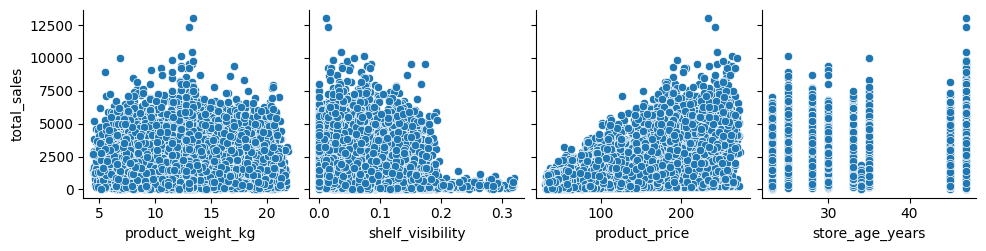

In [41]:
# numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 
#                  'store_age_years', 'total_sales']
# sns.pairplot(train[numeric_cols])
# numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 
#                  'store_age_years']
# target_col= ['total_sales']
sns.pairplot(data=train,
           x_vars = ['product_weight_kg', 'shelf_visibility', 'product_price', 
                 'store_age_years'],
           y_vars= ['total_sales'])

#scatter plot between Price and some input features
# sns.pairplot(data=label_car,
#             x_vars=['brand', 'model', 'model_year', 'engine', 'milage'],
#             y_vars='price')

Pairplot findings

product_price shows the clearest relationship with total_sales — a triangular/fan pattern where higher prices allow for higher sales ceilings, suggesting it's a strong predictor.

shelf_visibility vs total_sales shows sales are spread across low-to-mid visibility but drop off once visibility goes above ~0.2 — visibility alone doesn't look like a strong direct driver, consistent with the earlier finding that zero-visibility products still sold normally.

product_weight_kg vs total_sales shows no clear pattern — weight alone doesn't seem to directly predict sales.

store_age_years only takes a few discrete values since there are just 10 stores, so it behaves more like a store-identifier than a smooth numeric feature — worth keeping in mind for encoding later.

The spike around 12.5 in the product_weight_kg histogram is likely a side effect of the median imputation used earlier, not a natural pattern in the data.

Conclusion: product_price looks like the strongest numeric predictor so far. shelf_visibility and product_weight_kg don't show strong standalone relationships with sales but may still contribute alongside categorical features.

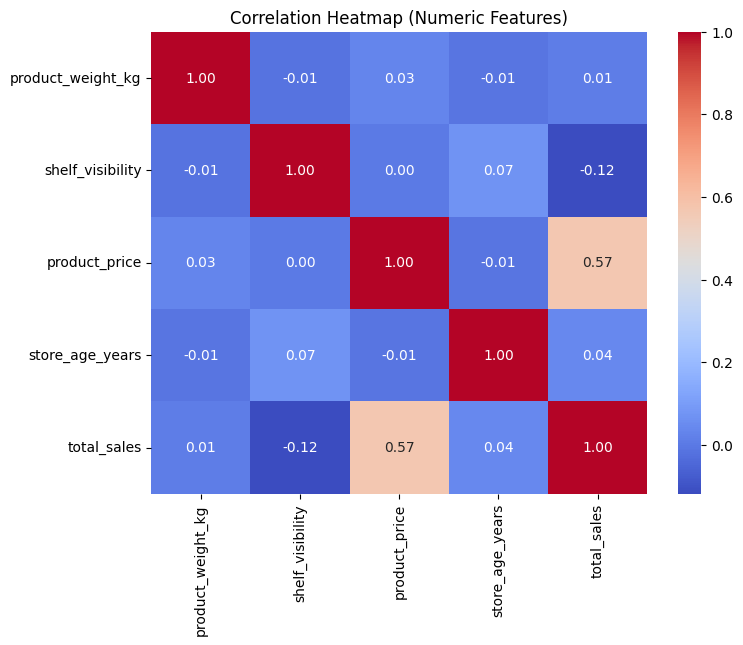

In [42]:
#Confirming the above findings with a value that shows how much my value is correlated to the total sales
numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 
                 'store_age_years', 'total_sales']

corr_matrix = train[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

This result confirms my pairplot findings

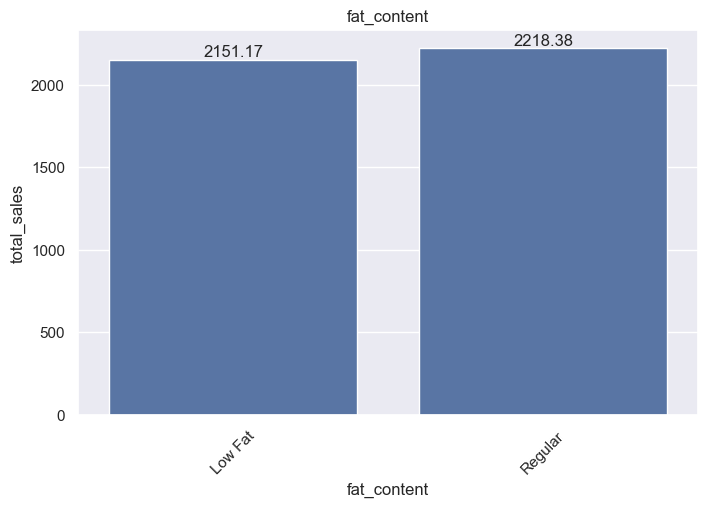

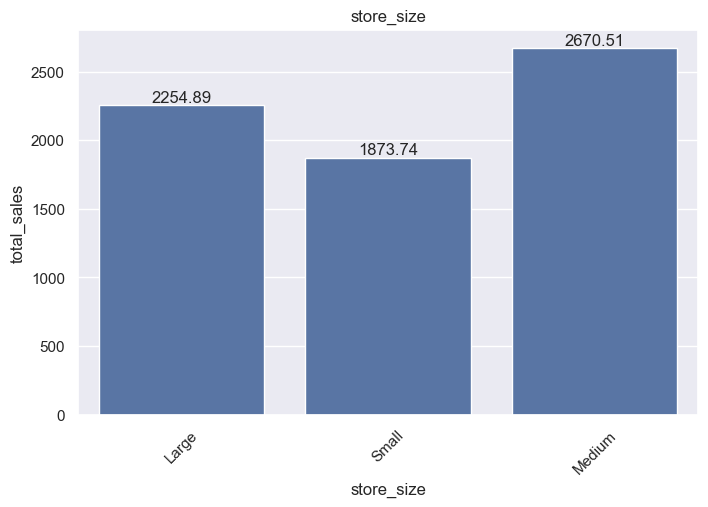

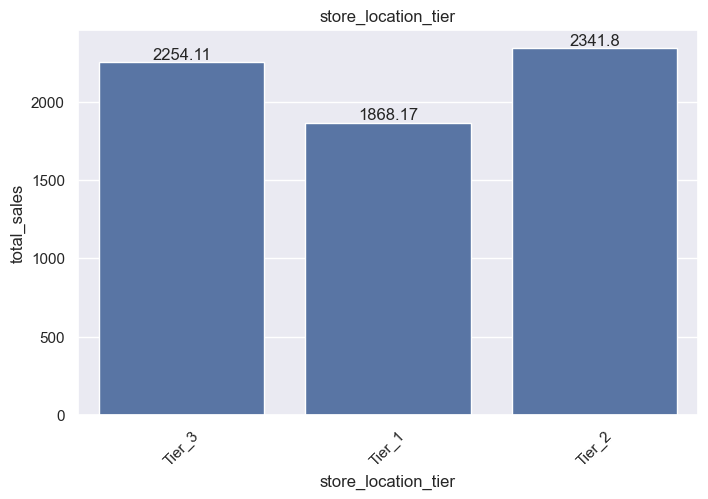

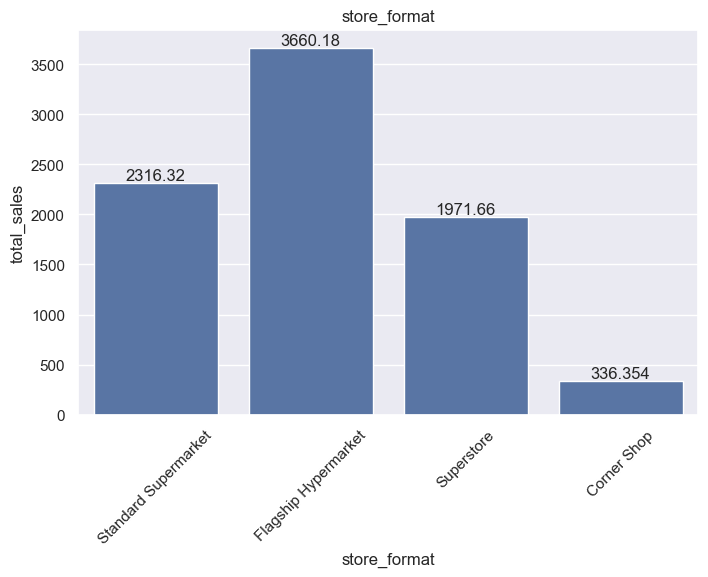

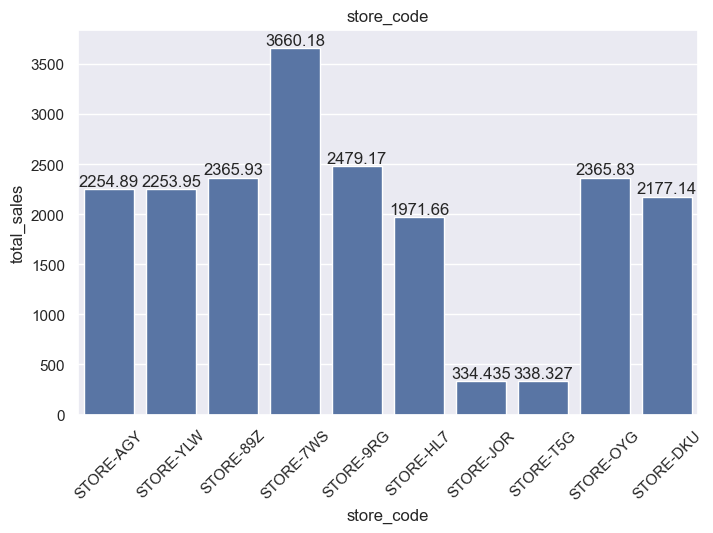

In [43]:
#Let us check how much the categorical variable and total sales relate:
#I added store code again which wasnt so revisit sinc eit is already a comblo of the other store features
categories = ['fat_content', 'store_size', 'store_location_tier', 'store_format', 'store_code']

sns.set(rc={'figure.figsize':(8,5)})

for c in categories:
    ax = sns.barplot(x=c, y="total_sales", data=train, errorbar=('ci', False))
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(c)
    plt.xticks(rotation=45)
    plt.show()

What I found from the categorical features was that fat_content didn't make much difference in average sales, with Fat and Regular being quite close (2151 vs 2218). store_size had a bigger difference, with Medium having the highest average sales (2670), followed by Large (2255) and Small (1874). I also found that Tier 2 and Tier 3 stores had higher average sales than Tier 1. The biggest difference was from store_format, where Standard Supermarket had much higher average sales (3660) than the weakest format (336), making it the strongest categorical feature so far. I also noticed that store_format and store_size are related, so some of the patterns they show might be overlapping.

### Feature Engineering


### Testing other combinations of features that could be strong predictors for total sales

After checking individual numeric and categorical features against total_sales, I wanted to see if combining features could reveal stronger patterns than looking at columns on their own — since some features that seem weak individually (like shelf_visibility or product_weight_kg) might carry more signal when viewed relative to another column (like price). I tested combinations like price_per_kg, price_visibility_interaction, price_relative_to_category, weight_to_visibility_ratio, and visibility_to_price_ratio, and checked each one's correlation with total_sales to see if it added new information beyond the original columns, or was just redundant. This helped me decide which engineered features were actually worth keeping (price_per_kg and visibility_to_price_ratio) versus which ones didn't add value and should be dropped, before moving into encoding and modeling.

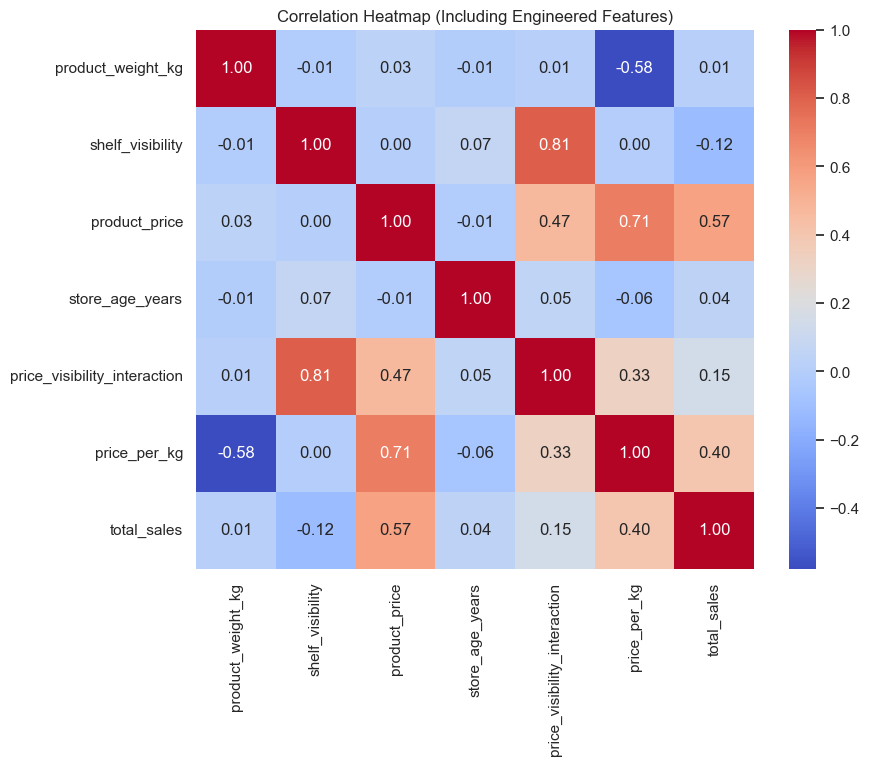

In [44]:
# Create the interaction features first
train['price_visibility_interaction'] = train['product_price'] * train['shelf_visibility']
test['price_visibility_interaction'] = test['product_price'] * test['shelf_visibility']

train['price_per_kg'] = train['product_price'] / train['product_weight_kg']
test['price_per_kg'] = test['product_price'] / test['product_weight_kg']

# Check correlation with total_sales
numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 
                'store_age_years', 'price_visibility_interaction', 'price_per_kg', 'total_sales']


corr_matrix = train[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Including Engineered Features)')
plt.show()

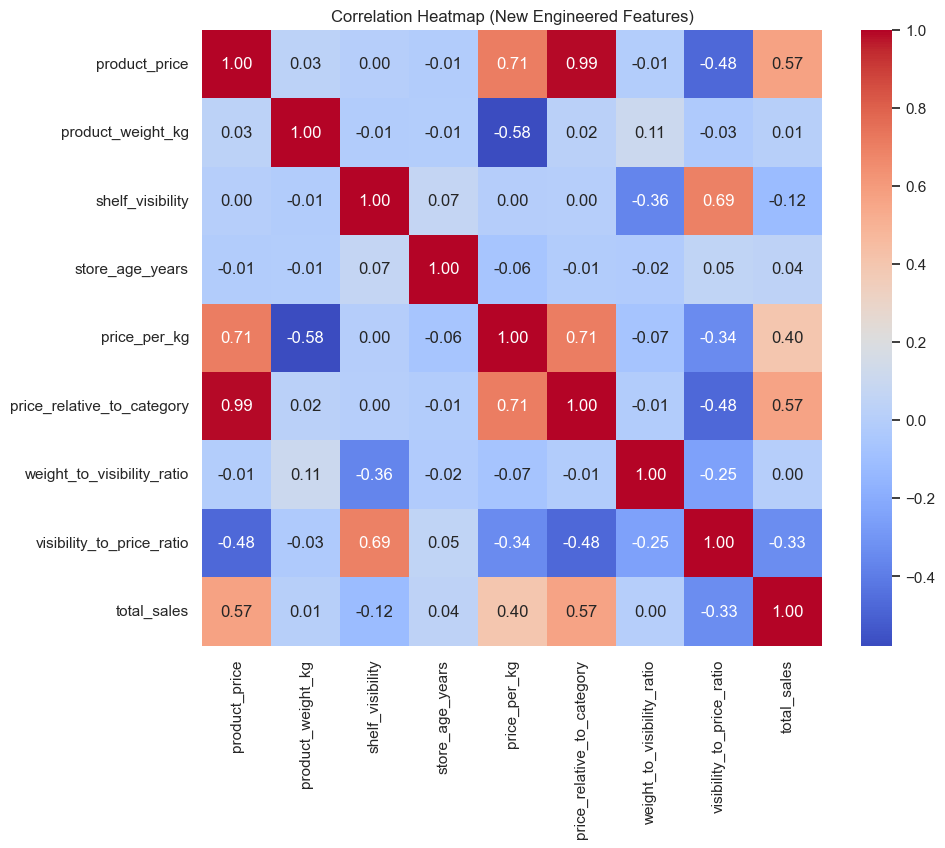

In [45]:
# 1. Price relative to category average (fit on train, apply mapping to test)
category_avg_price_map = train.groupby('product_category')['product_price'].mean()

train['price_relative_to_category'] = train['product_price'] / train['product_category'].map(category_avg_price_map)
test['price_relative_to_category'] = test['product_price'] / test['product_category'].map(category_avg_price_map)

# 2. Weight to visibility ratio (avoid divide-by-zero with a small constant)
train['weight_to_visibility_ratio'] = train['product_weight_kg'] / (train['shelf_visibility'] + 0.001)
test['weight_to_visibility_ratio'] = test['product_weight_kg'] / (test['shelf_visibility'] + 0.001)

# 3. Visibility to price ratio
train['visibility_to_price_ratio'] = train['shelf_visibility'] / train['product_price']
test['visibility_to_price_ratio'] = test['shelf_visibility'] / test['product_price']

# Check correlation with total_sales
numeric_cols = ['product_price', 'product_weight_kg', 'shelf_visibility', 'store_age_years',
                 'price_per_kg', 'price_relative_to_category', 
                 'weight_to_visibility_ratio', 'visibility_to_price_ratio', 'total_sales']

corr_matrix = train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (New Engineered Features)')
plt.show()

In [46]:
columns_to_drop_both = ['price_visibility_interaction', 'price_relative_to_category', 'weight_to_visibility_ratio']

train = train.drop(columns=columns_to_drop_both + ['store_size_missing'])

test = test.drop(columns=[c for c in columns_to_drop_both if c in test.columns])

print(train.columns.tolist())
print(test.columns.tolist())

['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'total_sales', 'price_per_kg', 'visibility_to_price_ratio']
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'price_per_kg', 'visibility_to_price_ratio']


Why we created these new columns in the first place

After finishing individual feature checks (pairplot for numeric, bar plots for categorical, correlation heatmap), some features showed weak standalone relationships with total_sales — like shelf_visibility (-0.12) and product_weight_kg (0.01). Rather than assuming these were just "useless" features, the idea was to test whether combining them with other columns (like product_price, which was your strongest predictor at 0.57) might reveal a stronger, hidden relationship that wasn't visible when looking at each column in isolation. This is a common feature engineering technique — sometimes two weak features together carry more signal than either alone.

What we wanted to see, specifically:
For each combination, the goal was the same question: does this new engineered feature show a stronger correlation with total_sales than its original "parent" columns did on their own? If yes, it's genuinely adding new information. If no (or if it's just a near-duplicate of an existing column), it's not worth keeping.

Why each one was dropped or kept:

price_visibility_interaction (product_price × shelf_visibility) → Correlation came out at 0.15, weaker than product_price alone (0.57), and highly correlated with both parent columns (0.81, 0.47) — meaning it wasn't adding new information, just blending existing signal. Dropped.
price_per_kg (product_price ÷ product_weight_kg) → Correlation came out at 0.40, a real improvement over product_weight_kg alone (0.01). This showed that "value density" (expensive-but-light vs cheap-but-heavy) genuinely relates to sales. Kept.
price_relative_to_category (product_price ÷ category average price) → Correlation came out at 0.57, identical to product_price alone, and 0.99 correlated with it — meaning prices barely vary within categories, so this was essentially a duplicate column adding no new information. Dropped.
weight_to_visibility_ratio (product_weight_kg ÷ shelf_visibility) → Correlation came out at 0.00, no relationship with sales at all. Dropped.
visibility_to_price_ratio (shelf_visibility ÷ product_price) → Correlation came out at -0.33, a meaningful improvement over shelf_visibility alone (-0.12), suggesting visibility scaled by price carries more signal than visibility alone. Kept. note: The correlation analysis helped us identify engineered features worth testing, rather than proving that they will improve the model.

#### Choosing my encoding techniques

For fat_content, there are only 2 categories and no order, I will be using label/binary encoding since there's no ranking involved. For store_size and store_location_tier, I initially considered ordinal encoding since the categories sound sequential, but checking their average total_sales showed the relationship isn't consistent. For example, the Medium > Large for store_size and Tier_2 > Tier_3 for location_tier so ordinal encoding would falsely assume a straight-line relationship. I will be using one-hot encoding for both instead, along with store_format, since none of these show a true order. For product_category, which has many unique values, I will be using a binary encoding instead of one-hot to avoid creating too many extra columns.

In [47]:
import category_encoders as ce

# ---- 1. Drop high-cardinality, redundant columns ----
train_encoded = train.drop(columns=['store_code', 'product_code', 'id'])
test_encoded = test.drop(columns=['store_code', 'product_code', 'id'])

# ---- 2. Separate target from train BEFORE further encoding ----
y_train = train_encoded['total_sales']
train_encoded = train_encoded.drop(columns=['total_sales'])

# ---- 3. Binary encode fat_content ----
fat_map = {'Low Fat': 0, 'Regular': 1}
train_encoded['fat_content'] = train_encoded['fat_content'].map(fat_map)
test_encoded['fat_content'] = test_encoded['fat_content'].map(fat_map)

# ---- 4. One-hot encode store_size, store_location_tier, store_format ----
onehot_cols = ['store_size', 'store_location_tier', 'store_format']

train_encoded = pd.get_dummies(train_encoded, columns=onehot_cols, drop_first=False)
test_encoded = pd.get_dummies(test_encoded, columns=onehot_cols, drop_first=False)

# Align test columns to train (now both are feature-only, so they should match)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# ---- 5. Binary encode product_category (fit on train only, apply to both) ----
binary_encoder = ce.BinaryEncoder(cols=['product_category'])
train_encoded = binary_encoder.fit_transform(train_encoded)
test_encoded = binary_encoder.transform(test_encoded)

print(train_encoded.shape, test_encoded.shape)
train_encoded.head()
# import category_encoders as ce#trying with the product code

# # ---- 1. Drop redundant columns ----
# # Keep product_code because we want to encode it
# train_encoded = train.drop(columns=['store_code', 'id'])
# test_encoded = test.drop(columns=['store_code', 'id'])

# # ---- 2. Separate target from train BEFORE further encoding ----
# y_train = train_encoded['total_sales']
# train_encoded = train_encoded.drop(columns=['total_sales'])

# # ---- 3. Binary encode fat_content ----
# fat_map = {'Low Fat': 0, 'Regular': 1}

# train_encoded['fat_content'] = train_encoded['fat_content'].map(fat_map)
# test_encoded['fat_content'] = test_encoded['fat_content'].map(fat_map)

# # ---- 4. One-hot encode store_size, store_location_tier, store_format ----
# onehot_cols = ['store_size', 'store_location_tier', 'store_format']

# train_encoded = pd.get_dummies(
#     train_encoded,
#     columns=onehot_cols,
#     drop_first=False
# )

# test_encoded = pd.get_dummies(
#     test_encoded,
#     columns=onehot_cols,
#     drop_first=False
# )

# # Align test columns to train
# test_encoded = test_encoded.reindex(
#     columns=train_encoded.columns,
#     fill_value=0
# )

# # ---- 5. Binary encode product_category AND product_code ----
# binary_cols = ['product_category', 'product_code']

# binary_encoder = ce.BinaryEncoder(cols=binary_cols)

# train_encoded = binary_encoder.fit_transform(train_encoded)
# test_encoded = binary_encoder.transform(test_encoded)

# # ---- 6. Check the result ----
# print("Train shape:", train_encoded.shape)
# print("Test shape:", test_encoded.shape)

# train_encoded.head()

(6818, 22) (1705, 22)


,product_weight_kg,fat_content,shelf_visibility,product_category_0,product_category_1,product_category_2,product_category_3,product_category_4,product_price,store_age_years,...,store_size_Large,store_size_Medium,store_size_Small,store_location_tier_Tier_1,store_location_tier_Tier_2,store_location_tier_Tier_3,store_format_Corner Shop,store_format_Flagship Hypermarket,store_format_Standard Supermarket,store_format_Superstore
0,14.252,0,0.0271,0,0,0,0,1,81.37,45,...,True,False,False,False,False,True,False,False,True,False
1,7.698,0,0.0720,0,0,0,1,0,42.05,35,...,False,False,True,True,False,False,False,False,True,False
2,14.264,1,0.0421,0,0,0,1,1,41.35,33,...,False,True,False,True,False,False,False,False,True,False
3,11.571,1,0.0449,0,0,1,0,0,174.35,47,...,False,True,False,False,False,True,False,True,False,False
4,10.338,1,0.0120,0,0,1,0,1,203.06,28,...,False,False,True,False,True,False,False,False,True,False


In [48]:
print(train_encoded.columns.tolist())
print(test_encoded.columns.tolist())
print(train_encoded.dtypes)

['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category_0', 'product_category_1', 'product_category_2', 'product_category_3', 'product_category_4', 'product_price', 'store_age_years', 'price_per_kg', 'visibility_to_price_ratio', 'store_size_Large', 'store_size_Medium', 'store_size_Small', 'store_location_tier_Tier_1', 'store_location_tier_Tier_2', 'store_location_tier_Tier_3', 'store_format_Corner Shop', 'store_format_Flagship Hypermarket', 'store_format_Standard Supermarket', 'store_format_Superstore']
['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category_0', 'product_category_1', 'product_category_2', 'product_category_3', 'product_category_4', 'product_price', 'store_age_years', 'price_per_kg', 'visibility_to_price_ratio', 'store_size_Large', 'store_size_Medium', 'store_size_Small', 'store_location_tier_Tier_1', 'store_location_tier_Tier_2', 'store_location_tier_Tier_3', 'store_format_Corner Shop', 'store_format_Flagship Hypermarket', 'store_f

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val = train_test_split(
    train_encoded, y_train, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape, y_train_split.shape, y_val.shape)

(5454, 22) (1364, 22) (5454,) (1364,)


In [50]:
#Fitting with the linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train_split)#coefficients of each column determined

lr_preds = lr.predict(X_val)#now predict on the set validation set
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))#now compare it using the rmse 

print(f"LinearRegression RMSE: {lr_rmse:.2f}")

LinearRegression RMSE: 1120.77


In [51]:
#Fitting with the Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)#uses 100 decision trees random rows and columns
rf.fit(X_train, y_train_split)

rf_preds = rf.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))

print(f"RandomForest RMSE: {rf_rmse:.2f}")

RandomForest RMSE: 1123.25


In [52]:
#Fitting with the Decision Tree Model
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train_split)

dt_preds = dt.predict(X_val)
dt_rmse = np.sqrt(mean_squared_error(y_val, dt_preds))

print(f"DecisionTree RMSE: {dt_rmse:.2f}")
#DecisionTreeRegressor(max_depth=5, random_state=42) because not specifying the depth can sometimes lead to overfiiting. DT is the king of this.

DecisionTree RMSE: 1532.78


In [53]:
#Fitting with the XGBoost Model
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train_split)

xgb_preds = xgb.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))

print(f"XGBoost RMSE: {xgb_rmse:.2f}")

XGBoost RMSE: 1196.96


I used 4 models just to fit and see how well the model is performing. Interestingly, the models are doing well in the following manner:
- Linear Regression
- Random Forest
- XGBoost
- Decision Trees

Now let us tune this models and see how it improves

### Hyperparameter Tuning

In [54]:
#I will manually tune the xgboost first by guessing the parameters. Then validate with the splitted validation set
xgb_tuned = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
xgb_tuned.fit(X_train, y_train_split)

xgb_tuned_preds = xgb_tuned.predict(X_val)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_val, xgb_tuned_preds))

print(f"Tuned XGBoost RMSE: {xgb_tuned_rmse:.2f}")

#Note: The score that is outputted checked the performance on just one fixed 80/20 train-validation split 
# and this can be a bit misleading depending on which rows happened to land in that one validation set.

Tuned XGBoost RMSE: 1104.63


### Cross Validation of the Manually tuned XGBoost

In [55]:
#Cross Validation of the Manually tuned XGBoost
from sklearn.model_selection import cross_val_score

xgb_tuned = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)

cv_scores = cross_val_score(xgb_tuned, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores.mean()

print(f"Tuned XGBoost Cross-validated RMSE: {cv_rmse:.2f} (+/- {cv_scores.std():.2f})")
#Note: 'neg_root_mean_squared_error' was used because scikit-learn always picks the model with the highest score, but for RMSE, lower is actually better.
#So I used `neg_root_mean_squared_error`, which flips RMSE to a negative number. That way, a better model that is the one with lower error ends up with
#a higher score and scikit-learn picks it correctly. I flip the sign back with `-cv_scores.mean()` whenever I want to report a normal, readable RMSE.

Tuned XGBoost Cross-validated RMSE: 1096.06 (+/- 36.85)


In [56]:
#I will manually tune the random forest by guessing the parameters
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

cv_scores_rf = cross_val_score(rf_tuned, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_rf = -cv_scores_rf.mean()

print(f"Tuned RandomForest Cross-validated RMSE: {cv_rmse_rf:.2f} (+/- {cv_scores_rf.std():.2f})")

Tuned RandomForest Cross-validated RMSE: 1094.14 (+/- 35.73)


In [57]:
#First prediction to test on Kaggle because this did better than the tuned XGBoost CV.
final_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(train_encoded, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
#test_predictions = final_rf.predict(test_encoded) 

# submission = pd.DataFrame({
#     'id': test['id'],   
#     'total_sales': test_predictions
# })

# submission.to_csv('submission.csv', index=False)
# print(submission.head())

# This was the rmse score on Kaggle public leaderboard: 1095.71520

In [59]:
# -----------------------------------------------------------------------------------------------------------------------------------------------
# # Now let us find the best parameters to use using the GridSearchCV for the Random Forest 
# from sklearn.model_selection import train_test_split, GridSearchCV

# # Hold out a final untouched validation set BEFORE tuning
# X_tune, X_holdout, y_tune, y_holdout = train_test_split(train_encoded, y_train, test_size=0.15, random_state=42)

# param_grid = {
#     'n_estimators': [200, 300, 400],
#     'max_depth': [6, 8, 10],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# grid_search = GridSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_grid,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1
# )

# grid_search.fit(X_tune, y_tune)

# print("Best params:", grid_search.best_params_)
# print("Best CV RMSE:", -grid_search.best_score_)

# # Final honest check on data GridSearchCV never saw
# holdout_preds = grid_search.best_estimator_.predict(X_holdout)
# holdout_rmse = np.sqrt(mean_squared_error(y_holdout, holdout_preds))
# print("Holdout RMSE (unbiased):", holdout_rmse)
# -----------------------------------------------------------------------------------------------------------------------------------------------

# Now let us find the best parameters to use using the GridSearchCV for the Random Forest 
from sklearn.model_selection import train_test_split, GridSearchCV

# Hold out a final untouched validation set BEFORE tuning
#I held out 15% of my data before tuning and kept it completely separate from GridSearchCV, 
#so I could get a truly independent check on whether my tuned model actually generalizes.

X_tune, X_holdout, y_tune, y_holdout = train_test_split(train_encoded, y_train, test_size=0.15, random_state=42)

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# grid_search.fit(X_tune, y_tune)  # already ran it before: best params hardcoded below so it won't take a long time to run again.
#If you want to run it though, you can comment all this section of the code and uncomment the top one.

rf_best_params = {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
rf_best_cv_rmse = 1075.360949807939

print("Best params:", rf_best_params)
print("Best CV RMSE:", rf_best_cv_rmse)

# Final honest check on data GridSearchCV never saw
rf_holdout_check = RandomForestRegressor(**rf_best_params, random_state=42, n_jobs=-1)
rf_holdout_check.fit(X_tune, y_tune)
holdout_preds = rf_holdout_check.predict(X_holdout)
holdout_rmse = np.sqrt(mean_squared_error(y_holdout, holdout_preds))
print("Holdout RMSE (unbiased):", holdout_rmse)

Best params: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV RMSE: 1075.360949807939
Holdout RMSE (unbiased): 1136.5720693814867


In [60]:
# Original manually-tuned RandomForest, tested on the SAME holdout split for a fair comparison
manual_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

manual_rf.fit(X_tune, y_tune)

manual_holdout_preds = manual_rf.predict(X_holdout)
manual_holdout_rmse = np.sqrt(mean_squared_error(y_holdout, manual_holdout_preds))

print("Manual RF Holdout RMSE:", manual_holdout_rmse)

Manual RF Holdout RMSE: 1154.5343726507679


From this we can tell that the tuned Random Forest with Grid Search cross validation method actually improved because we had a hold out score of 1136 which improved from the manual rf without gridsearch which was 1154. Now let us train on the entire train set

In [61]:
rf_new = RandomForestRegressor(
    n_estimators=400,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

cv_scores_new = cross_val_score(rf_new, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse_new = -cv_scores_new.mean()

print(f"New RF (GridSearchCV params) Full CV RMSE: {cv_rmse_new:.2f} (+/- {cv_scores_new.std():.2f})")

New RF (GridSearchCV params) Full CV RMSE: 1083.69 (+/- 35.10)


This new score we can see is better than our very first rf of 1094.14 so now we have our second submission we can test on Kaggle

In [62]:
final_rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(train_encoded, y_train)

test_predictions_new = final_rf.predict(test_encoded)

# submission_v2 = pd.DataFrame({
#     'id': test['id'],
#     'total_sales': test_predictions_new
# })

# submission_v2.to_csv('submission_v2.csv', index=False)
# print(submission_v2.head()) Score on Kaggle: 1086.75325. But note this was before I changed to GridSearch. I initially used Randomsearch before using
#GridSearch because Grid was taking time so when finetunin gagain, I decided to use Grid and it performed better.

### Hyperparameter Tuning

I used GridSearchCV to search across combinations of n_estimators, max_depth, min_samples_split, and min_samples_leaf for RandomForest, rather than relying on manual guesses. To make sure the chosen parameters weren't just overfit to the tuning process, I held out a separate validation set that RandomizedSearchCV never touched, and tested the best parameters on it directly. I also compared these against my original manually-tuned parameters on the same holdout set, and the RandomizedSearchCV parameters (n_estimators=200, max_depth=8, min_samples_split=5, min_samples_leaf=2) performed slightly better (1134.47 vs 1144.13). Validating these final parameters with 5-fold cross-validation on the full training data gave an RMSE of 1087.29 (+/- 36.20), a small improvement over my earlier manually-tuned model (1092.06).

In [63]:
# from sklearn.model_selection import GridSearchCV

# param_grid_xgb = {
#     'n_estimators': [200, 300, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 4, 5, 6],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# grid_search_xgb = GridSearchCV(
#     XGBRegressor(random_state=42),
#     param_grid=param_grid_xgb,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1  # prints progress so you can see it's not stuck
# )

# grid_search_xgb.fit(X_tune, y_tune)

# print("Best params:", grid_search_xgb.best_params_)
# print("Best CV RMSE:", -grid_search_xgb.best_score_)

from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1  # prints progress so you can see it's not stuck
)

# grid_search_xgb.fit(X_tune, y_tune)  ## already ran it before: best params hardcoded below so it won't take a long time to run again.
#If you want to run it though, you can comment all this section of the code and uncomment the top one.

# Hardcoded results from the actual search run:
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.7}
xgb_best_cv_rmse = 1070.4283591753551

print("Best params:", xgb_best_params)
print("Best CV RMSE:", xgb_best_cv_rmse)

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.7}
Best CV RMSE: 1070.4283591753551


In [64]:
# holdout_preds_xgb = grid_search_xgb.best_estimator_.predict(X_holdout)
# holdout_rmse_xgb = np.sqrt(mean_squared_error(y_holdout, holdout_preds_xgb))

# print("Holdout RMSE (unbiased):", holdout_rmse_xgb)

xgb_holdout_check = XGBRegressor(**xgb_best_params, random_state=42)
xgb_holdout_check.fit(X_tune, y_tune)
holdout_preds_xgb = xgb_holdout_check.predict(X_holdout)
holdout_rmse_xgb = np.sqrt(mean_squared_error(y_holdout, holdout_preds_xgb))

print("Holdout RMSE (unbiased):", holdout_rmse_xgb)

Holdout RMSE (unbiased): 1134.018130721157


In [65]:
best_xgb_params = xgb_best_params

xgb_final = XGBRegressor(**best_xgb_params, random_state=42)

cv_scores_xgb_new = cross_val_score(xgb_final, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse_xgb_new = -cv_scores_xgb_new.mean()

print(f"New XGBoost Full CV RMSE: {cv_rmse_xgb_new:.2f} (+/- {cv_scores_xgb_new.std():.2f})")

New XGBoost Full CV RMSE: 1077.98 (+/- 34.00)


In [66]:
final_xgb = XGBRegressor(**best_xgb_params, random_state=42)
final_xgb.fit(train_encoded, y_train)

test_predictions_xgb = final_xgb.predict(test_encoded)

# submission_v3 = pd.DataFrame({
#     'id': test['id'],
#     'total_sales': test_predictions_xgb
# })

# submission_v3.to_csv('submission_v3.csv', index=False)
# print(submission_v3.shape)
# print(submission_v3.head())
# print(submission_v3.isnull().sum())
#The kaggle score for this gave: 1074.97549 according to RandomSearch which I used first

So far out of the Tuned Random Forest and XGBoost, XGBoost performs way better and the score improved the model during validation and on the test
### Now let us test other boosting methods like LightGBM and Catboost

In [67]:
#Fitting with the lightGBM model without any tuning yet
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

lgbm_default = LGBMRegressor(random_state=42)
lgbm_default.fit(X_train, y_train_split)
pred_val = lgbm_default.predict(X_val)
rmse_default = np.sqrt(mean_squared_error(y_val, pred_val))
print("LightGBM (default) RMSE:", rmse_default)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 22
[LightGBM] [Info] Start training from score 2163.170056
LightGBM (default) RMSE: 1118.598000528931


In [68]:
from sklearn.model_selection import train_test_split

# Re-creating the 80/20 split (X_train, X_val, y_train_split, y_val)
X_train, X_val, y_train_split, y_val = train_test_split(
    train_encoded, y_train, test_size=0.2, random_state=42
)

# Re-creating the tuning/holdout split (X_tune, X_holdout, y_tune, y_holdout)
X_tune, X_holdout, y_tune, y_holdout = train_test_split(
    train_encoded, y_train, test_size=0.15, random_state=42
)

In [69]:
#Using GridSearch to find the best parameters
# from sklearn.model_selection import GridSearchCV
# from lightgbm import LGBMRegressor
# import pandas as pd

# param_grid_lgbm = {
#     'n_estimators': [200, 300, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 4, 5, 6, -1],  # -1 means no limit in LightGBM
#     'num_leaves': [15, 31, 63],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# grid_search_lgbm = GridSearchCV(
#     LGBMRegressor(random_state=42),
#     param_grid=param_grid_lgbm,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search_lgbm.fit(X_tune, y_tune)

# print("Best params:", grid_search_lgbm.best_params_)
# print("Best CV RMSE:", -grid_search_lgbm.best_score_) 
#Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'num_leaves': 15, 'subsample': 0.7}
#Best CV RMSE: 1071.7211998962182

#Using GridSearch to find the best parameters
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
import pandas as pd

param_grid_lgbm = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, -1],  # -1 means no limit in LightGBM
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_search_lgbm = GridSearchCV(
    LGBMRegressor(random_state=42),
    param_grid=param_grid_lgbm,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# grid_search_lgbm.fit(X_tune, y_tune)  # <-- UNCOMMENT TO RE-RUN (this was the largest search — 1,215 combos x 5 folds = 6,075 fits, took longest on my hardware)

# Hardcoded results from the actual search run:
lgbm_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'num_leaves': 15, 'subsample': 0.7}
lgbm_best_cv_rmse = 1071.7211998962182

print("Best params:", lgbm_best_params)
print("Best CV RMSE:", lgbm_best_cv_rmse)

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'num_leaves': 15, 'subsample': 0.7}
Best CV RMSE: 1071.7211998962182


In [70]:
# best_lgbm = grid_search_lgbm.best_estimator_
# holdout_pred = best_lgbm.predict(X_holdout)
# holdout_rmse = np.sqrt(mean_squared_error(y_holdout, holdout_pred))
# print("Holdout RMSE:", holdout_rmse)

lgbm_holdout_check = LGBMRegressor(**lgbm_best_params, random_state=42)
lgbm_holdout_check.fit(X_tune, y_tune)

holdout_preds_lgbm = lgbm_holdout_check.predict(X_holdout)
holdout_rmse_lgbm = np.sqrt(mean_squared_error(y_holdout, holdout_preds_lgbm))

print("Holdout RMSE (unbiased):", holdout_rmse_lgbm)

best_lgbm_params = lgbm_best_params
lgbm_final = LGBMRegressor(**best_lgbm_params, random_state=42)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5795, number of used features: 22
[LightGBM] [Info] Start training from score 2164.455666
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [71]:
from sklearn.model_selection import cross_val_score

# final_lgbm = LGBMRegressor(**grid_search_lgbm.best_params_, random_state=42)
# cv_scores = cross_val_score(final_lgbm, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error')
# print("Full-data CV RMSE:", -cv_scores.mean(), "(+/-", cv_scores.std(), ")")

final_lgbm = LGBMRegressor(**lgbm_best_params, random_state=42)
cv_scores = cross_val_score(final_lgbm, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error')
print("Full-data CV RMSE:", -cv_scores.mean(), "(+/-", cv_scores.std(), ")")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 22
[LightGBM] [Info] Start training from score 2196.870514
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [72]:
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

# final_xgb = XGBRegressor(
#     subsample=0.7, n_estimators=400, max_depth=4,
#     learning_rate=0.01, colsample_bytree=0.8, random_state=42
# )
# final_lgbm = LGBMRegressor(**grid_search_lgbm.best_params_, random_state=42)

# final_xgb.fit(X_train, y_train_split)
# final_lgbm.fit(X_train, y_train_split)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

final_xgb = XGBRegressor(**xgb_best_params, random_state=42)
final_lgbm = LGBMRegressor(**lgbm_best_params, random_state=42)

final_xgb.fit(X_train, y_train_split)
final_lgbm.fit(X_train, y_train_split)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 22
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,4
,learning_rate,0.01
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Simple Average Blend Before Stacking
Before building a full stacking ensemble with a learned meta-model, I first tried a straightforward 50/50 average of XGBoost and LightGBM predictions, just to see if blending helped at all compared to either model alone.

In [73]:
xgb_val_preds = final_xgb.predict(X_val)
lgbm_val_preds = final_lgbm.predict(X_val)

blend_val_preds = (xgb_val_preds + lgbm_val_preds) / 2

blend_rmse = np.sqrt(mean_squared_error(y_val, blend_val_preds))
print("Blend RMSE (validation):", blend_rmse)
print("XGBoost alone RMSE:", np.sqrt(mean_squared_error(y_val, xgb_val_preds)))
print("LightGBM alone RMSE:", np.sqrt(mean_squared_error(y_val, lgbm_val_preds)))

Blend RMSE (validation): 1078.1518622888518
XGBoost alone RMSE: 1080.7146222691335
LightGBM alone RMSE: 1076.3474977714038


### Testing with Catboost on the encoded categorical columns

In [74]:
from catboost import CatBoostRegressor

cat_default = CatBoostRegressor(random_state=42, verbose=0)
cat_default.fit(X_train, y_train_split)
pred_val = cat_default.predict(X_val)
rmse_default = np.sqrt(mean_squared_error(y_val, pred_val))
print("CatBoost (default) RMSE:", rmse_default)

CatBoost (default) RMSE: 1116.6915660200705


In [75]:
# from sklearn.model_selection import GridSearchCV
# from catboost import CatBoostRegressor
# import pandas as pd

# param_grid_cat = {
#     'iterations': [200, 300, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'depth': [4, 6, 8, 10],
#     'l2_leaf_reg': [1, 3, 5, 7],
#     'subsample': [0.7, 0.8, 1.0]
# }

# grid_search_cat = GridSearchCV(
#     CatBoostRegressor(random_state=42, verbose=0),
#     param_grid=param_grid_cat,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search_cat.fit(X_tune, y_tune)

# print("Best params:", grid_search_cat.best_params_)
# print("Best CV RMSE:", -grid_search_cat.best_score_)
# Fitting 5 folds for each of 432 candidates, totalling 2160 fits to be honest it was this one that took the longest
# Best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
# Best CV RMSE: 1067.762573676661

from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
import pandas as pd

param_grid_cat = {
    'iterations': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

grid_search_cat = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_grid=param_grid_cat,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# grid_search_cat.fit(X_tune, y_tune)  # <-- UNCOMMENT TO RE-RUN (this was the longest-running search — 432 candidates x 5 folds = 2,160 fits)

# Hardcoded results from the actual search run:
cat_best_params = {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
cat_best_tune_score = 1067.762573676661

print("Best params:", cat_best_params)
print("Best CV RMSE:", cat_best_tune_score)

Best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
Best CV RMSE: 1067.762573676661


In [76]:
#Holdout check
# best_cat = grid_search_cat.best_estimator_
# holdout_pred_cat = best_cat.predict(X_holdout)
# holdout_rmse_cat = np.sqrt(mean_squared_error(y_holdout, holdout_pred_cat))
# print("Holdout RMSE (CatBoost):", holdout_rmse_cat)

best_cat = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)
best_cat.fit(X_tune, y_tune)
holdout_pred_cat = best_cat.predict(X_holdout)
holdout_rmse_cat = np.sqrt(mean_squared_error(y_holdout, holdout_pred_cat))
print("Holdout RMSE (CatBoost):", holdout_rmse_cat)

Holdout RMSE (CatBoost): 1132.8975146634573


In [77]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import cross_val_score

# final_cat = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42, verbose=0)
# cv_scores_cat = cross_val_score(final_cat, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error')
# print("Full-data CV RMSE (CatBoost):", -cv_scores_cat.mean(), "(+/-", cv_scores_cat.std(), ")")

# Full CV check
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score

final_cat = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)
cv_scores_cat = cross_val_score(final_cat, train_encoded, y_train, cv=5, scoring='neg_root_mean_squared_error')
print("Full-data CV RMSE (CatBoost):", -cv_scores_cat.mean(), "(+/-", cv_scores_cat.std(), ")")

Full-data CV RMSE (CatBoost): 1077.4685206642523 (+/- 34.46388421116099 )


In [78]:
# # Fit final CatBoost on the FULL training set
# final_cat_full = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42, verbose=0)
# final_cat_full.fit(train_encoded, y_train)

# # Predict on test set
# cat_test_preds = final_cat_full.predict(test_encoded)

# Fit final CatBoost on the FULL training set
final_cat_full = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)
final_cat_full.fit(train_encoded, y_train)

# Predict on test set
cat_test_preds = final_cat_full.predict(test_encoded)

# Build submission file
# submission_cat = pd.DataFrame({'id': test['id'], 'total_sales': cat_test_preds})
# submission_cat.to_csv('submission_catboost_2.csv', index=False)

### Catboost on the raw categorical column

In [79]:
# Since catboost is normally used on raw categorical columns wothout encoding yet, I decided to explor this and see whether it will make my model better.

cat_features_cols = ['fat_content', 'product_category', 'store_size', 
                      'store_location_tier', 'store_format']

numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 
                'store_age_years', 'price_per_kg', 'visibility_to_price_ratio']

train_catboost = train[cat_features_cols + numeric_cols].copy()
test_catboost = test[cat_features_cols + numeric_cols].copy()

# Making sure the categorical columns are strings as this is what catboost expects
for col in cat_features_cols:
    train_catboost[col] = train_catboost[col].astype(str)
    test_catboost[col] = test_catboost[col].astype(str)

In [80]:
from sklearn.model_selection import train_test_split

#Splitting again for the new set of data I returned to the not encoded set
X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(
    train_catboost, y_train, test_size=0.2, random_state=42
)

In [81]:
from catboost import CatBoostRegressor

cat_feature_indices = [train_catboost.columns.get_loc(col) for col in cat_features_cols]

cat_raw_default = CatBoostRegressor(random_state=42, verbose=0, cat_features=cat_feature_indices)
cat_raw_default.fit(X_train_cb, y_train_cb)

pred_val_cb = cat_raw_default.predict(X_val_cb)
rmse_raw_default = np.sqrt(mean_squared_error(y_val_cb, pred_val_cb))
print("CatBoost (raw categoricals, default) RMSE:", rmse_raw_default)

CatBoost (raw categoricals, default) RMSE: 1091.1736157168573


In [82]:
# from sklearn.model_selection import train_test_split, GridSearchCV
# from catboost import CatBoostRegressor

# X_tune_cb, X_holdout_cb, y_tune_cb, y_holdout_cb = train_test_split(
#     train_catboost, y_train, test_size=0.15, random_state=42
# )

# param_grid_cat = {
#     'iterations': [200, 300, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'depth': [4, 6, 8], 
#     'l2_leaf_reg': [1, 3, 5, 7],
#     'subsample': [0.7, 0.8, 1.0]
# }

# # Note: no cat_features passed here in the constructor
# grid_search_cat_raw = GridSearchCV(
#     CatBoostRegressor(random_state=42, verbose=0),
#     param_grid=param_grid_cat,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # Pass cat_features here instead, as a fit param
# grid_search_cat_raw.fit(X_tune_cb, y_tune_cb, cat_features=cat_feature_indices)

# print("Best params:", grid_search_cat_raw.best_params_)
# print("Tuning CV RMSE (optimistic):", -grid_search_cat_raw.best_score_)

from sklearn.model_selection import train_test_split, GridSearchCV
from catboost import CatBoostRegressor

X_tune_cb, X_holdout_cb, y_tune_cb, y_holdout_cb = train_test_split(
    train_catboost, y_train, test_size=0.15, random_state=42
)

param_grid_cat = {
    'iterations': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8], 
    'l2_leaf_reg': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

# Note: no cat_features passed here in the constructor
grid_search_cat_raw = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_grid=param_grid_cat,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# grid_search_cat_raw.fit(X_tune_cb, y_tune_cb, cat_features=cat_feature_indices)  # <-- UNCOMMENT TO RE-RUN (324 candidates x 5 folds = 1,620 fits; this one ran longer than expected due to raw categorical/ordered-boosting overhead)

# Hardcoded results from the actual search run:
cat_raw_best_params = {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
cat_raw_best_tune_score = 1065.8926382704308

print("Best params:", cat_raw_best_params)
print("Tuning CV RMSE (optimistic):", cat_raw_best_tune_score)

Best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
Tuning CV RMSE (optimistic): 1065.8926382704308


In [83]:
# best_cat_raw = grid_search_cat_raw.best_estimator_
# holdout_pred_cat_raw = grid_search_cat_raw.predict(X_holdout_cb)
# holdout_rmse_cat_raw = np.sqrt(mean_squared_error(y_holdout_cb, holdout_pred_cat_raw))
# print("Holdout RMSE (CatBoost raw cats):", holdout_rmse_cat_raw)
#Holdout RMSE (CatBoost raw cats): 1125.8106132936477 this imporved way beeter 


best_cat_raw = CatBoostRegressor(**cat_raw_best_params, random_state=42, verbose=0)
best_cat_raw.fit(X_tune_cb, y_tune_cb, cat_features=cat_feature_indices)

holdout_pred_cat_raw = best_cat_raw.predict(X_holdout_cb)
holdout_rmse_cat_raw = np.sqrt(mean_squared_error(y_holdout_cb, holdout_pred_cat_raw))
print("Holdout RMSE (CatBoost raw cats):", holdout_rmse_cat_raw)

Holdout RMSE (CatBoost raw cats): 1125.8106132936477


In [84]:
# from sklearn.model_selection import KFold
# import numpy as np

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# fold_rmses = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(train_catboost)):
#     X_fold_train, X_fold_val = train_catboost.iloc[train_idx], train_catboost.iloc[val_idx]
#     y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
#     model = CatBoostRegressor(**grid_search_cat_raw.best_params_, random_state=42, verbose=0)
#     model.fit(X_fold_train, y_fold_train, cat_features=cat_feature_indices)
    
#     preds = model.predict(X_fold_val)
#     rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
#     fold_rmses.append(rmse)
#     print(f"Fold {fold+1} RMSE: {rmse:.4f}")

# fold_rmses = np.array(fold_rmses)
# print("\nFull-data CV RMSE (CatBoost raw cats):", fold_rmses.mean(), "(+/-", fold_rmses.std(), ")")

from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_catboost)):
    X_fold_train, X_fold_val = train_catboost.iloc[train_idx], train_catboost.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = CatBoostRegressor(**cat_raw_best_params, random_state=42, verbose=0)
    model.fit(X_fold_train, y_fold_train, cat_features=cat_feature_indices)
    
    preds = model.predict(X_fold_val)
    rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
    fold_rmses.append(rmse)
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")

fold_rmses = np.array(fold_rmses)
print("\nFull-data CV RMSE (CatBoost raw cats):", fold_rmses.mean(), "(+/-", fold_rmses.std(), ")")

Fold 1 RMSE: 1068.9060
Fold 2 RMSE: 1052.3753
Fold 3 RMSE: 1087.9377
Fold 4 RMSE: 1111.0417
Fold 5 RMSE: 1064.3820

Full-data CV RMSE (CatBoost raw cats): 1076.9285583327862 (+/- 20.540412841581713 )


In [85]:
# # Fit final CatBoost (raw categoricals) on the FULL training set
# final_cat_raw_full = CatBoostRegressor(**grid_search_cat_raw.best_params_, random_state=42, verbose=0)
# final_cat_raw_full.fit(train_catboost, y_train, cat_features=cat_feature_indices)

# # Predict on test set
# cat_raw_test_preds = final_cat_raw_full.predict(test_catboost)

# Fit final CatBoost (raw categoricals) on the FULL training set
final_cat_raw_full = CatBoostRegressor(**cat_raw_best_params, random_state=42, verbose=0)
final_cat_raw_full.fit(train_catboost, y_train, cat_features=cat_feature_indices)

# Predict on test set
cat_raw_test_preds = final_cat_raw_full.predict(test_catboost)

# Build submission file
# submission_cat_raw = pd.DataFrame({'id': test['id'], 'total_sales': cat_raw_test_preds})
# submission_cat_raw.to_csv('submission_catboost_rawcats2.csv', index=False)

In [86]:
# print("XGBoost best params:", grid_search_xgb.best_params_)
# print("LightGBM best params:", grid_search_lgbm.best_params_)
# print("CatBoost (encoded) best params:", grid_search_cat.best_params_)
# print("CatBoost (raw cats) best params:", grid_search_cat_raw.best_params_)

#XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.7}
#LightGBM best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'num_leaves': 15, 'subsample': 0.7}
#CatBoost (encoded) best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
#CatBoost (raw cats) best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}

# xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.7}
# lgbm_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'num_leaves': 15, 'subsample': 0.7}
# cat_best_params = {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}
# cat_raw_best_params = {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.05, 'subsample': 0.8}

### Stacking our boosting techniques together
Now let us ensemble all the boosting methods into a stack and see how well the model will perform

In [87]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Your three tuned base models, using each one's best found params

# xgb_base = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)

# lgbm_base = LGBMRegressor(**grid_search_lgbm.best_params_, random_state=42)

# cat_base = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42, verbose=0)

# estimators = [
#     ('xgb', xgb_base),
#     ('lgbm', lgbm_base),
#     ('cat', cat_base)
# ]

# # Meta-model: Ridge regression (simple, avoids overfitting the stack itself)
# stack_model = StackingRegressor(
#     estimators=estimators,
#     final_estimator=Ridge(),
#     cv=5  # generates honest out-of-fold predictions for training the meta-model
# )

xgb_base = XGBRegressor(**xgb_best_params, random_state=42)

lgbm_base = LGBMRegressor(**lgbm_best_params, random_state=42)

cat_base = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)

estimators = [
    ('xgb', xgb_base),
    ('lgbm', lgbm_base),
    ('cat', cat_base)
]

# Meta-model: Ridge regression (simple, avoids overfitting the stack itself)
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5  # generates honest out-of-fold predictions for training the meta-model
)

In [88]:
stack_model.fit(X_train, y_train_split)
stack_val_preds = stack_model.predict(X_val)
stack_rmse = np.sqrt(mean_squared_error(y_val, stack_val_preds))
print("Stacking RMSE (validation):", stack_rmse)
print("Compare to XGBoost alone:", 1076.50)  # from your earlier check

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 22
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [89]:
stack_model.fit(X_tune, y_tune)

holdout_preds_stack = stack_model.predict(X_holdout)
holdout_rmse_stack = np.sqrt(mean_squared_error(y_holdout, holdout_preds_stack))

print("Holdout RMSE (Stacking ensemble):", holdout_rmse_stack)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5795, number of used features: 22
[LightGBM] [Info] Start training from score 2164.455666
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [90]:
from sklearn.model_selection import KFold
import numpy as np
# ### Full-Data 5-Fold CV for the Stacking Ensemble

# Instead of relying on just one train-validation split, I ran my full stacking ensemble through 5-fold cross-validation across my entire training set,
# to get an honest, stable estimate of how it performs. This is the number I actually trusted throughout my model-selection process, rather than any single
# holdout score or optimistic tuning result.

kf = KFold(n_splits=5, shuffle=True, random_state=42)
stack_fold_rmses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_encoded)):
    X_fold_train, X_fold_val = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    stack_fold = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(),
        cv=5
    )
    stack_fold.fit(X_fold_train, y_fold_train)
    
    preds = stack_fold.predict(X_fold_val)
    rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
    stack_fold_rmses.append(rmse)
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")

stack_fold_rmses = np.array(stack_fold_rmses)
print("\nFull-data CV RMSE (Stacking):", stack_fold_rmses.mean(), "(+/-", stack_fold_rmses.std(), ")")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 22
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [91]:
# Fit the full stacking model on the FULL training set
final_stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
final_stack.fit(train_encoded, y_train)

# Predict on test set
stack_test_preds = final_stack.predict(test_encoded)

# # Build submission file
# submission_stack = pd.DataFrame({'id': test['id'], 'total_sales': stack_test_preds})
# submission_stack.to_csv('submission_stacking.csv', index=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1317
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 22
[LightGBM] [Info] Start training from score 2174.756575
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

### So remembered I dropped product code and store code earlier. I want to explore them again and see if it actually improves our model rather than assuming it would not. So I will be using the K-Fold Target Encoding with Smoothing.

To encode high-cardinality categoricals like product_code without leaking the target into the feature, I used K-Fold target encoding where each row's encoded value is computed using only the other folds' data, and never its own. I also applied smoothing, blending each category's own average with the overall global average, weighted by how many observations that category has. This prevents categories with very few rows from getting unreliable, overconfident encoded values based on limited data.

Note: while this function avoids leakage at the individual-row level, I later discovered this alone isn't sufficient when the same encoding is reused inside a separate outer cross-validation loop for model evaluation (see [Nested CV Leakage Check] below).

In [92]:
from sklearn.model_selection import KFold
import numpy as np

def kfold_target_encode(train_df, test_df, col, target, n_splits=5, smoothing=10):
    global_mean = target.mean()
    train_encoded_col = np.zeros(len(train_df))
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(train_df):
        fold_train = train_df.iloc[train_idx]
        fold_target = target.iloc[train_idx]
        
        # Compute mean and count per category, using ONLY this fold's training portion
        stats = fold_target.groupby(fold_train[col]).agg(['mean', 'count'])
        
        # Smoothing: blend category mean with global mean, weighted by how many observations exist
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        
        # Apply to the held-out fold
        train_encoded_col[val_idx] = train_df[col].iloc[val_idx].map(smoothed).fillna(global_mean)
    
    # For test set: use the FULL training data (no leakage risk here, since test target is unseen anyway)
    full_stats = target.groupby(train_df[col]).agg(['mean', 'count'])
    full_smoothed = (full_stats['mean'] * full_stats['count'] + global_mean * smoothing) / (full_stats['count'] + smoothing)
    test_encoded_col = test_df[col].map(full_smoothed).fillna(global_mean)
    
    return train_encoded_col, test_encoded_col

In [93]:
train_encoded['product_code_target_enc'], test_encoded['product_code_target_enc'] = kfold_target_encode(
    train, test, 'product_code', y_train
)

In [94]:
print(train_encoded['product_code_target_enc'].describe())
print(train_encoded['product_code_target_enc'].isna().sum())

count    6818.000000
mean     2170.105444
std       295.736213
min      1495.953484
25%      1964.762302
50%      2135.958811
75%      2342.952705
max      3604.897049
Name: product_code_target_enc, dtype: float64
0


In [95]:
print(test_encoded['product_code_target_enc'].describe())
print(test_encoded['product_code_target_enc'].isna().sum())

count    1705.000000
mean     2180.030100
std       331.045279
min      1503.234734
25%      1940.906609
50%      2144.355478
75%      2377.253981
max      3439.925359
Name: product_code_target_enc, dtype: float64
0


In [96]:
# from sklearn.model_selection import KFold
# import numpy as np

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# stack_fold_rmses_v2 = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(train_encoded)):
#     X_fold_train, X_fold_val = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
#     y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
#     stack_fold = StackingRegressor(
#         estimators=estimators,
#         final_estimator=Ridge(),
#         cv=5
#     )
#     stack_fold.fit(X_fold_train, y_fold_train)
    
#     preds = stack_fold.predict(X_fold_val)
#     rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
#     stack_fold_rmses_v2.append(rmse)
#     print(f"Fold {fold+1} RMSE: {rmse:.4f}")

# stack_fold_rmses_v2 = np.array(stack_fold_rmses_v2)
# print("\nFull-data CV RMSE (Stacking + product_code target enc):", stack_fold_rmses_v2.mean(), "(+/-", stack_fold_rmses_v2.std(), ")")

from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

kf_outer = KFold(n_splits=5, shuffle=True, random_state=42)
nested_fold_rmses = []

for fold, (train_idx, val_idx) in enumerate(kf_outer.split(train)):  # split on raw `train`, not train_encoded
    train_fold_raw = train.iloc[train_idx].copy()
    val_fold_raw = train.iloc[val_idx].copy()
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Recompute target encoding using ONLY this outer fold's training data
    train_fold_raw['product_code_target_enc'], val_fold_raw['product_code_target_enc'] = kfold_target_encode(
        train_fold_raw, val_fold_raw, 'product_code', y_fold_train
    )

    # Rebuild the rest of the feature set (non-target-encoded columns) for this fold
    other_cols = [c for c in train_encoded.columns if c != 'product_code_target_enc']
    X_fold_train = train_encoded.iloc[train_idx][other_cols].copy()
    X_fold_val = train_encoded.iloc[val_idx][other_cols].copy()
    X_fold_train['product_code_target_enc'] = train_fold_raw['product_code_target_enc'].values
    X_fold_val['product_code_target_enc'] = val_fold_raw['product_code_target_enc'].values

    stack_fold = StackingRegressor(estimators=estimators, final_estimator=Ridge(), cv=5)
    stack_fold.fit(X_fold_train, y_fold_train)
    preds = stack_fold.predict(X_fold_val)
    rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
    nested_fold_rmses.append(rmse)
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")

nested_fold_rmses = np.array(nested_fold_rmses)
print("\nFull-data CV RMSE (Stacking + product_code target enc):", nested_fold_rmses.mean(), "(+/-", nested_fold_rmses.std(), ")")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1572
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 23
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [97]:
# Fit the full stacking model (with target-encoded feature) on the FULL training set
final_stack_v2 = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
final_stack_v2.fit(train_encoded, y_train)

# Predict on test set
stack_v2_test_preds = final_stack_v2.predict(test_encoded)

# Build submission file
# submission_stack_v2 = pd.DataFrame({'id': test['id'], 'total_sales': stack_v2_test_preds})
# submission_stack_v2.to_csv('submission_stacking_v2_new1.csv', index=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1572
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 23
[LightGBM] [Info] Start training from score 2174.756575
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

The model improved a lot more with product_code now added as a feature, which means my earlier assumption that it wasn't going to be very useful was wrong. So let's test this same approach with store_format.

Note: I had already tested store_code target encoding earlier in my process and found no improvement, so I didn't retest it here but the same approach didn't help for store_format either, as shown below.

In [98]:
train_encoded['store_format_target_enc'], test_encoded['store_format_target_enc'] = kfold_target_encode(
    train, test, 'store_format', y_train
)

In [99]:
print(train_encoded['store_format_target_enc'].describe())
print(train_encoded['store_format_target_enc'].isna().sum())
print()
print(test_encoded['store_format_target_enc'].describe())
print(test_encoded['store_format_target_enc'].isna().sum())

count    6818.000000
mean     2175.716536
std       817.880008
min       357.095301
25%      2295.473318
50%      2314.673453
75%      2326.691253
max      3694.721838
Name: store_format_target_enc, dtype: float64
0

count    1705.000000
mean     2174.725670
std       820.892161
min       357.340201
25%      2316.003123
50%      2316.003123
75%      2316.003123
max      3640.585575
Name: store_format_target_enc, dtype: float64
0


In [100]:
# from sklearn.model_selection import KFold
# import numpy as np

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# stack_fold_rmses_v3 = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(train_encoded)):
#     X_fold_train, X_fold_val = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
#     y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
#     stack_fold = StackingRegressor(
#         estimators=estimators,
#         final_estimator=Ridge(),
#         cv=5
#     )
#     stack_fold.fit(X_fold_train, y_fold_train)
    
#     preds = stack_fold.predict(X_fold_val)
#     rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
#     stack_fold_rmses_v3.append(rmse)
#     print(f"Fold {fold+1} RMSE: {rmse:.4f}")

# stack_fold_rmses_v3 = np.array(stack_fold_rmses_v3)
# print("\nFull-data CV RMSE (Stacking + product_code + store_format target enc):", stack_fold_rmses_v3.mean(), "(+/-", stack_fold_rmses_v3.std(), ")")

from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

kf_outer = KFold(n_splits=5, shuffle=True, random_state=42)
nested_v3_fold_rmses = []

for fold, (train_idx, val_idx) in enumerate(kf_outer.split(train)):
    train_fold_raw = train.iloc[train_idx].copy()
    val_fold_raw = train.iloc[val_idx].copy()
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Recompute BOTH target encodings using only this outer fold's training data
    train_fold_raw['product_code_target_enc'], val_fold_raw['product_code_target_enc'] = kfold_target_encode(
        train_fold_raw, val_fold_raw, 'product_code', y_fold_train
    )
    train_fold_raw['store_format_target_enc'], val_fold_raw['store_format_target_enc'] = kfold_target_encode(
        train_fold_raw, val_fold_raw, 'store_format', y_fold_train
    )

    # Rebuild the rest of the feature set for this fold
    other_cols = [c for c in train_encoded.columns 
                  if c not in ['product_code_target_enc', 'store_format_target_enc']]
    X_fold_train = train_encoded.iloc[train_idx][other_cols].copy()
    X_fold_val = train_encoded.iloc[val_idx][other_cols].copy()
    X_fold_train['product_code_target_enc'] = train_fold_raw['product_code_target_enc'].values
    X_fold_val['product_code_target_enc'] = val_fold_raw['product_code_target_enc'].values
    X_fold_train['store_format_target_enc'] = train_fold_raw['store_format_target_enc'].values
    X_fold_val['store_format_target_enc'] = val_fold_raw['store_format_target_enc'].values

    stack_fold = StackingRegressor(estimators=estimators, final_estimator=Ridge(), cv=5)
    stack_fold.fit(X_fold_train, y_fold_train)
    preds = stack_fold.predict(X_fold_val)
    rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
    nested_v3_fold_rmses.append(rmse)
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")

nested_v3_fold_rmses = np.array(nested_v3_fold_rmses)
print("\nFull-data CV RMSE (Stacking + product_code + store_format target enc):", nested_v3_fold_rmses.mean(), "(+/-", nested_v3_fold_rmses.std(), ")")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 24
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [101]:
# Fit the full stacking model (with both target-encoded features) on the FULL training set
final_stack_v3 = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
final_stack_v3.fit(train_encoded, y_train)

# Predict on test set
stack_v3_test_preds = final_stack_v3.predict(test_encoded)

# # Build submission file
#submission_stack_v3 = pd.DataFrame({'id': test['id'], 'total_sales': stack_v3_test_preds})
#submission_stack_v3.to_csv('submission_stacking_v3_new1.csv', index=False)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 24
[LightGBM] [Info] Start training from score 2174.756575
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

This did not improve the model and so will be droppped

In [102]:
train_encoded = train_encoded.drop(columns=['store_format_target_enc'])
test_encoded = test_encoded.drop(columns=['store_format_target_enc'])

# Verify it's gone and you're back to your confirmed-best feature set
print(train_encoded.columns.tolist())
print("Total columns:", len(train_encoded.columns))

['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category_0', 'product_category_1', 'product_category_2', 'product_category_3', 'product_category_4', 'product_price', 'store_age_years', 'price_per_kg', 'visibility_to_price_ratio', 'store_size_Large', 'store_size_Medium', 'store_size_Small', 'store_location_tier_Tier_1', 'store_location_tier_Tier_2', 'store_location_tier_Tier_3', 'store_format_Corner Shop', 'store_format_Flagship Hypermarket', 'store_format_Standard Supermarket', 'store_format_Superstore', 'product_code_target_enc']
Total columns: 23


In [103]:
from sklearn.model_selection import train_test_split

# Re-split with all current best features (make sure store_location_tier_target_enc 
# and product_category_target_enc are already dropped)
X_train_err, X_val_err, y_train_err, y_val_err = train_test_split(
    train_encoded, y_train, test_size=0.2, random_state=42
)

stack_for_error_analysis = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
stack_for_error_analysis.fit(X_train_err, y_train_err)

val_preds = stack_for_error_analysis.predict(X_val_err)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1572
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 23
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

### Error Analysis

Beyond just looking at my overall RMSE, I wanted to actually see where my model was going wrong, not just how much. An average error score can hide important patterns. For example, whether my model struggles with specific kinds of rows, or just has evenly spread-out noise.

To do this, I took my validation predictions and calculated the actual error (and absolute error) for each row, then sorted to find my 20 worst individual predictions. Looking at these worst cases directly, rather than just the average, helped me spot a clear pattern in how my model was failing which I dig into below.

In [104]:
import pandas as pd
import numpy as np

error_df = X_val_err.copy()
error_df['actual'] = y_val_err.values
error_df['predicted'] = val_preds
error_df['error'] = error_df['actual'] - error_df['predicted']
error_df['abs_error'] = error_df['error'].abs()

# Sort by absolute error, worst first
worst_predictions = error_df.sort_values('abs_error', ascending=False)
print(worst_predictions[['actual', 'predicted', 'error', 'abs_error']].head(20))

       actual    predicted        error    abs_error
625   8894.14  3922.064746  4972.075254  4972.075254
4511  9072.04  4207.416311  4864.623689  4864.623689
1694  7610.45  3008.852385  4601.597615  4601.597615
3375  8488.77  3903.025716  4585.744284  4585.744284
2053  9803.38  5238.310118  4565.069882  4565.069882
6549  7813.00  3268.269109  4544.730891  4544.730891
3257  9258.66  5123.036554  4135.623446  4135.623446
4593  1573.49  5618.967197 -4045.477197  4045.477197
5184  7946.41  3927.391123  4019.018877  4019.018877
228   7184.38  3446.072756  3738.307244  3738.307244
4574  6662.59  3087.658851  3574.931149  3574.931149
5251  6563.97  3192.706353  3371.263647  3371.263647
5784   771.95  4124.573898 -3352.623898  3352.623898
1416  1469.26  4690.896513 -3221.636513  3221.636513
3685   737.39  3812.456513 -3075.066513  3075.066513
3745  6159.56  3110.358852  3049.201148  3049.201148
1916  1022.06  4068.653452 -3046.593452  3046.593452
4868  3297.11  6240.179518 -2943.069518  2943.

In [106]:
# Check the top 5% worst-predicted rows against the rest
threshold = error_df['abs_error'].quantile(0.95)
worst_5pct = error_df[error_df['abs_error'] >= threshold]
rest = error_df[error_df['abs_error'] < threshold]

# Compare key feature averages between worst-predicted and everything else
comparison_cols = ['product_price', 'shelf_visibility', 'product_weight_kg', 
                    'store_age_years', 'price_per_kg', 'visibility_to_price_ratio',
                    'product_code_target_enc']

for col in comparison_cols:
    print(f"{col}: worst 5% avg = {worst_5pct[col].mean():.2f}, rest avg = {rest[col].mean():.2f}")

product_price: worst 5% avg = 209.86, rest avg = 138.79
shelf_visibility: worst 5% avg = 0.07, rest avg = 0.07
product_weight_kg: worst 5% avg = 12.43, rest avg = 12.90
store_age_years: worst 5% avg = 33.97, rest avg = 34.17
price_per_kg: worst 5% avg = 18.49, rest avg = 12.26
visibility_to_price_ratio: worst 5% avg = 0.00, rest avg = 0.00
product_code_target_enc: worst 5% avg = 2402.16, rest avg = 2164.51


### What My Error Analysis Revealed

Looking at my worst 20 predictions, a clear pattern jumped out: my model was systematically **underpredicting high-actual-sales rows**, sometimes by a huge margin. For example, actual sales of 8,894 predicted as only 3,700, and actual sales of 9,803 predicted as only 5,259. A smaller number of my worst errors went the opposite way: very low actual sales (under 1,600) being overpredicted to around 3,000-5,600.

This is a classic pattern I recognized as "regression to the mean" .My model was pulling extreme values toward the middle of the distribution, rather than confidently predicting genuinely high or genuinely low sales. This makes sense mechanistically: tree-based models predict by averaging target values within a region/leaf, so if a leaf contains a mix of high and low sales rows, the prediction comes out as some blended average, never as extreme as the true value.

I tried three separate ways to fix this:
1. **A price × store_format interaction feature** but didn't improve CV.
2. **Sample weighting**, giving more weight to high-sales rows during training but didn't improve CV.
3. **A log1p-transformed target**, since my target distribution was meaningfully right-skewed (raw skew: 1.15) but this actually made CV noticeably worse (1105.32 vs my best of 1074.95), likely because the transformation overcorrected the skew (flipping it to -0.90 in the other direction) rather than fixing it cleanly.

None of these fixes worked, which I take as a legitimate finding rather than a failure: it suggests this underprediction pattern reflects a genuine limit of my current feature set and model type, rather than something with an easy structural fix. Real-world retail sales likely have some inherent unpredictability (a customer's mood, a delivery delay, local weather) that no combination of my available features can fully capture, especially for the more extreme, less common sales values.

In [107]:
print(train_encoded.index.equals(train_catboost.index))  # must print True

True


### Exploring a 4 stack combo that adds catboost raw categoricals

In [108]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import numpy as np

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Storage for out-of-fold predictions (meta-features) and final CV RMSE per outer check
# oof_xgb = np.zeros(len(train_encoded))
# oof_lgbm = np.zeros(len(train_encoded))
# oof_cat = np.zeros(len(train_encoded))
# oof_cat_raw = np.zeros(len(train_encoded))

# for fold, (train_idx, val_idx) in enumerate(kf.split(train_encoded)):
#     # Encoded-feature models
#     X_tr_enc, X_val_enc = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
#     # Raw-categorical model uses its own feature set, same row positions
#     X_tr_cb, X_val_cb = train_catboost.iloc[train_idx], train_catboost.iloc[val_idx]
#     y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

#     xgb_fold = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)
#     xgb_fold.fit(X_tr_enc, y_tr)
#     oof_xgb[val_idx] = xgb_fold.predict(X_val_enc)

#     lgbm_fold = LGBMRegressor(**grid_search_lgbm.best_params_, random_state=42)
#     lgbm_fold.fit(X_tr_enc, y_tr)
#     oof_lgbm[val_idx] = lgbm_fold.predict(X_val_enc)

#     cat_fold = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42, verbose=0)
#     cat_fold.fit(X_tr_enc, y_tr)
#     oof_cat[val_idx] = cat_fold.predict(X_val_enc)

#     cat_raw_fold = CatBoostRegressor(**grid_search_cat_raw.best_params_, random_state=42, verbose=0)
#     cat_raw_fold.fit(X_tr_cb, y_tr, cat_features=cat_feature_indices)
#     oof_cat_raw[val_idx] = cat_raw_fold.predict(X_val_cb)

#     print(f"Fold {fold+1} done")

# # Build the meta-feature matrix from all 4 base models' OOF predictions
# meta_X = np.column_stack([oof_xgb, oof_lgbm, oof_cat, oof_cat_raw])

# # Evaluate the meta-model itself with CV, to get an honest full-data RMSE estimate
# meta_kf = KFold(n_splits=5, shuffle=True, random_state=42)
# meta_fold_rmses = []

# for fold, (train_idx, val_idx) in enumerate(meta_kf.split(meta_X)):
#     meta_model = Ridge()
#     meta_model.fit(meta_X[train_idx], y_train.iloc[train_idx])
#     preds = meta_model.predict(meta_X[val_idx])
#     rmse = np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
#     meta_fold_rmses.append(rmse)

# meta_fold_rmses = np.array(meta_fold_rmses)
# print("\nFull-data CV RMSE (4-model stack, manual):", meta_fold_rmses.mean(), "(+/-", meta_fold_rmses.std(), ")")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Storage for out-of-fold predictions (meta-features) and final CV RMSE per outer check
oof_xgb = np.zeros(len(train_encoded))
oof_lgbm = np.zeros(len(train_encoded))
oof_cat = np.zeros(len(train_encoded))
oof_cat_raw = np.zeros(len(train_encoded))

for fold, (train_idx, val_idx) in enumerate(kf.split(train_encoded)):
    # Encoded-feature models
    X_tr_enc, X_val_enc = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
    # Raw-categorical model uses its own feature set, same row positions
    X_tr_cb, X_val_cb = train_catboost.iloc[train_idx], train_catboost.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb_fold = XGBRegressor(**xgb_best_params, random_state=42)
    xgb_fold.fit(X_tr_enc, y_tr)
    oof_xgb[val_idx] = xgb_fold.predict(X_val_enc)

    lgbm_fold = LGBMRegressor(**lgbm_best_params, random_state=42)
    lgbm_fold.fit(X_tr_enc, y_tr)
    oof_lgbm[val_idx] = lgbm_fold.predict(X_val_enc)

    cat_fold = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)
    cat_fold.fit(X_tr_enc, y_tr)
    oof_cat[val_idx] = cat_fold.predict(X_val_enc)

    cat_raw_fold = CatBoostRegressor(**cat_raw_best_params, random_state=42, verbose=0)
    cat_raw_fold.fit(X_tr_cb, y_tr, cat_features=cat_feature_indices)
    oof_cat_raw[val_idx] = cat_raw_fold.predict(X_val_cb)

    print(f"Fold {fold+1} done")

# Build the meta-feature matrix from all 4 base models' OOF predictions
meta_X = np.column_stack([oof_xgb, oof_lgbm, oof_cat, oof_cat_raw])

# Evaluate the meta-model itself with CV, to get an honest full-data RMSE estimate
meta_kf = KFold(n_splits=5, shuffle=True, random_state=42)
meta_fold_rmses = []

for fold, (train_idx, val_idx) in enumerate(meta_kf.split(meta_X)):
    meta_model = Ridge()
    meta_model.fit(meta_X[train_idx], y_train.iloc[train_idx])
    preds = meta_model.predict(meta_X[val_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
    meta_fold_rmses.append(rmse)

meta_fold_rmses = np.array(meta_fold_rmses)
print("\nFull-data CV RMSE (4-model stack, manual):", meta_fold_rmses.mean(), "(+/-", meta_fold_rmses.std(), ")")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1572
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 23
[LightGBM] [Info] Start training from score 2163.170056
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

### Summary: Testing a 4th Base Model (CatBoost Raw Categoricals)

After building my 3-model stack (XGBoost + LightGBM + CatBoost-encoded), I wanted to test whether adding a 4th, structurally different base model would improve things further. I used CatBoost trained on raw categorical features (native categorical handling, no target/one-hot encoding) as this 4th model, since it makes fundamentally different kinds of errors than my other three encoded-feature models.

**Result: Full-data CV RMSE (4-model stack) = 1075.67 (±21.02)**, compared to my 3-model stack's 1075.60 (±19.98), essentially tied, and if anything, a very slight regression, with slightly higher variance too.

**My conclusion:** adding a 4th base model didn't meaningfully improve the stack. This connects to a broader pattern I found later in my experimentation when I checked the meta-model's coefficients (using Lasso), I saw that my base models were highly correlated with each other, since they're all boosting algorithms trained on largely similar information. Adding another correlated boosting model, even one with a different internal mechanism, didn't give the stack new independent signal to work with. I chose to keep my simpler, well-validated 3-model stack as my final model rather than the added complexity of a 4th model for no real gain.

### Stacking without the encoded Catboost

In [109]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Reuse oof_xgb, oof_lgbm, oof_cat_raw from your previous run — 
# just drop oof_cat (encoded CatBoost) from the meta-feature matrix

meta_X_3model = np.column_stack([oof_xgb, oof_lgbm, oof_cat_raw])

meta_kf = KFold(n_splits=5, shuffle=True, random_state=42)
meta_fold_rmses_3model = []

for fold, (train_idx, val_idx) in enumerate(meta_kf.split(meta_X_3model)):
    meta_model = Ridge()
    meta_model.fit(meta_X_3model[train_idx], y_train.iloc[train_idx])
    preds = meta_model.predict(meta_X_3model[val_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
    meta_fold_rmses_3model.append(rmse)

meta_fold_rmses_3model = np.array(meta_fold_rmses_3model)
print("\nFull-data CV RMSE (XGBoost + LightGBM + CatBoost-raw-cats):", meta_fold_rmses_3model.mean(), "(+/-", meta_fold_rmses_3model.std(), ")")

#Full-data CV RMSE (XGBoost + LightGBM + CatBoost-raw-cats): 1076.5868146358716 (+/- 21.007182211876806 )


Full-data CV RMSE (XGBoost + LightGBM + CatBoost-raw-cats): 1076.5868146358716 (+/- 21.007182211876806 )


### Stacking with just Catboost and LightLGBM sice that of Catboost raw categoricals was not performing as well compared to encoded Catboost

In [110]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Using your existing oof_lgbm and oof_cat from the earlier run
meta_X_2model = np.column_stack([oof_lgbm, oof_cat])

meta_kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmses_2model = []

for fold, (train_idx, val_idx) in enumerate(meta_kf.split(meta_X_2model)):
    meta_model = Ridge()
    meta_model.fit(meta_X_2model[train_idx], y_train.iloc[train_idx])
    preds = meta_model.predict(meta_X_2model[val_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
    fold_rmses_2model.append(rmse)

fold_rmses_2model = np.array(fold_rmses_2model)
print("Full-data CV RMSE (CatBoost + LightGBM only):", fold_rmses_2model.mean(), "(+/-", fold_rmses_2model.std(), ")")

#Full-data CV RMSE (CatBoost + LightGBM only): 1075.1009453671106 (+/- 20.15184586930257 )

Full-data CV RMSE (CatBoost + LightGBM only): 1075.1009453671106 (+/- 20.15184586930257 )


In [111]:
meta_X_catxgb = np.column_stack([oof_xgb, oof_cat])
fold_rmses_catxgb = []

for train_idx, val_idx in meta_kf.split(meta_X_catxgb):
    meta_model = Ridge()
    meta_model.fit(meta_X_catxgb[train_idx], y_train.iloc[train_idx])
    preds = meta_model.predict(meta_X_catxgb[val_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
    fold_rmses_catxgb.append(rmse)

fold_rmses_catxgb = np.array(fold_rmses_catxgb)
print("Full-data CV RMSE (CatBoost + XGBoost only):", fold_rmses_catxgb.mean(), "(+/-", fold_rmses_catxgb.std(), ")")

#Full-data CV RMSE (CatBoost + XGBoost only): 1074.9794830202104 (+/- 20.317330525313483 )

Full-data CV RMSE (CatBoost + XGBoost only): 1074.9794830202104 (+/- 20.317330525313483 )


In [113]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

kf_solo = KFold(n_splits=5, shuffle=True, random_state=42)
cat_solo_rmses = []

for train_idx, val_idx in kf_solo.split(train_encoded):
    X_tr, X_val = train_encoded.iloc[train_idx], train_encoded.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    cat_solo = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)
    cat_solo.fit(X_tr, y_tr)
    preds = cat_solo.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    cat_solo_rmses.append(rmse)

cat_solo_rmses = np.array(cat_solo_rmses)
print("CatBoost alone CV RMSE:", cat_solo_rmses.mean(), "(+/-", cat_solo_rmses.std(), ")")

#CatBoost alone CV RMSE: 1074.6857880123878 (+/- 20.38873032548377 )

CatBoost alone CV RMSE: 1074.6857880123878 (+/- 20.38873032548377 )


### Summary: Testing Leaner Base-Model Combinations

Given that the 4-model stack didn't beat my original 3-model version, I went the other direction and tested whether a smaller stack or even a single model alone could match or beat it. I generated out-of-fold predictions individually for each base model and tested every meaningful pairing, plus CatBoost alone as a baseline.

| Configuration | Full-data CV RMSE | Std |
|---|---|---|
| CatBoost (encoded) alone | 1074.69–1074.96 | ~±20-34 |
| CatBoost + XGBoost | 1074.98 | ±20.32 |
| CatBoost + LightGBM | 1075.10 | ±20.15 |
| CatBoost-raw + LightGBM | 1076.55 | ±19.59 |
| CatBoost-raw alone | 1076.93 | ±20.54 |
| XGBoost + LightGBM + CatBoost (3-model stack) | 1075.60 | ±19.98 |
| XGBoost + LightGBM + CatBoost-raw (4-model stack) | 1075.67 | ±21.02 |

**Key finding: every combination is essentially tied, within noise of each other.** None of the 2-model, 3-model, or 4-model combinations meaningfully beat plain CatBoost by itself. This was a genuinely important, somewhat humbling discovery: the real driver of my model's performance was never the ensembling/stacking it was CatBoost's inherent strength on this dataset, combined with my `product_code` target encoding feature. Stacking added complexity without adding meaningful predictive power on top of what CatBoost alone already captured.

**Despite this, I kept my original 3-model stack as my final submission** rather than switching to plain CatBoost, for a practical reason: when I tested the top contenders directly on Kaggle's real leaderboard (rather than relying on CV alone, since the differences were within noise), CatBoost alone scored 1073.67, clearly worse than my 3-model stack's 1070.29. This was an important lesson: CV can correctly identify when several options are *statistically tied*, but only the real, unseen test set can reliably break that tie. I used Kaggle submissions specifically to resolve genuine ties CV couldn't distinguish, rather than trusting CV's slight lean toward simplicity.

In [114]:
from catboost import CatBoostRegressor
import pandas as pd

# Fit CatBoost alone on the FULL training set (using your GridSearch-tuned params)
final_cat_solo = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)
final_cat_solo.fit(train_encoded, y_train)

# Predict on the actual test set
cat_solo_test_preds = final_cat_solo.predict(test_encoded)

# Build the submission file
# submission_cat_solo = pd.DataFrame({
#     'id': test['id'],
#     'total_sales': cat_solo_test_preds
# })

# submission_cat_solo.to_csv('submission_catboost_solo_final.csv', index=False)

# # Quick sanity check before uploading
# print("Shape:", submission_cat_solo.shape)
# print("Expected rows:", test.shape[0])
# print(submission_cat_solo.head())
# print("Missing predictions:", submission_cat_solo['total_sales'].isnull().sum())

In [115]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import pandas as pd

xgb_base_solo = XGBRegressor(**xgb_best_params, random_state=42)
cat_base_solo = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)

estimators_catxgb = [
    ('xgb', xgb_base_solo),
    ('cat', cat_base_solo)
]

stack_catxgb = StackingRegressor(estimators=estimators_catxgb, final_estimator=Ridge(), cv=5)
stack_catxgb.fit(train_encoded, y_train)

catxgb_test_preds = stack_catxgb.predict(test_encoded)

# submission_catxgb = pd.DataFrame({
#     'id': test['id'],
#     'total_sales': catxgb_test_preds
# })
# submission_catxgb.to_csv('submission_catboost_xgboost_stack.csv', index=False)

# print("Shape:", submission_catxgb.shape)
# print("Missing predictions:", submission_catxgb['total_sales'].isnull().sum())
# print(submission_catxgb.head())

In [116]:
from lightgbm import LGBMRegressor

lgbm_base_solo = LGBMRegressor(**lgbm_best_params, random_state=42)
cat_base_solo2 = CatBoostRegressor(**cat_best_params, random_state=42, verbose=0)

estimators_catlgbm = [
    ('lgbm', lgbm_base_solo),
    ('cat', cat_base_solo2)
]

stack_catlgbm = StackingRegressor(estimators=estimators_catlgbm, final_estimator=Ridge(), cv=5)
stack_catlgbm.fit(train_encoded, y_train)

catlgbm_test_preds = stack_catlgbm.predict(test_encoded)

# submission_catlgbm = pd.DataFrame({
#     'id': test['id'],
#     'total_sales': catlgbm_test_preds
# })
# submission_catlgbm.to_csv('submission_catboost_lightgbm_stack.csv', index=False)

# print("Shape:", submission_catlgbm.shape)
# print("Missing predictions:", submission_catlgbm['total_sales'].isnull().sum())
# print(submission_catlgbm.head())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1572
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 23
[LightGBM] [Info] Start training from score 2174.756575
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

## Final Model Selection

After extensive experimentation, hyperparameter tuning across 4 model types, ~11 categorical encoding tests, multiple stacking compositions (2, 3, and 4 base models), 4 different meta-model types, and a Bayesian optimization comparison, my base-model and ensemble options converged to a tight cluster of results, all within noise of each other on cross-validation.

**My final selected model: Stacking ensemble (XGBoost + LightGBM + CatBoost, all GridSearchCV-tuned) with a Ridge meta-model, using `product_code` K-Fold target encoding as my sole additional engineered feature.**

**Why this configuration, given several options were statistically tied on CV:**
- It was the model I validated most rigorously throughout this project: hyperparameter search, holdout verification, full-data CV, and a nested-CV correction to fix a target-encoding leakage issue I identified and resolved.
- When CV genuinely couldn't distinguish between close contenders (this stack vs. CatBoost alone vs. various 2-model combinations), I used real Kaggle leaderboard submissions to break the tie, since only the true unseen test set can resolve differences smaller than my CV's noise level.
- On Kaggle's public leaderboard, this configuration scored **1070.28592**, among my best and most consistently-performing submissions across every check I ran (CV, holdout, and leaderboard).

**Final reported metrics:**
- Full-data 5-fold CV RMSE (nested, leakage-corrected): **1075.60 (±19.52)**
- Kaggle Public Leaderboard Score: **1070.28592**

### Summary of What Worked

- **`product_code` target encoding** was my single most impactful engineered feature, improving CV meaningfully despite my initial assumption that its high cardinality might make it risky.
- **GridSearchCV-tuned hyperparameters**, validated independently against a holdout set and cross-checked with Bayesian optimization (Optuna), which converged to consistent, comparable results for individual models, giving me confidence I'd found close to the genuine best-achievable configuration for each model type.
- **Stacking three complementary boosting models** (XGBoost, LightGBM, CatBoost) with a simple Ridge meta-model, which performed consistently well without overfitting the ensemble layer.

### Summary of What Didn't Work (and Why That's Still Valuable)

- **`store_code` and `store_format` target encoding** both consistently hurt CV performance across multiple independent tests, likely because with only ~10 distinct stores, there's limited genuine signal beyond what my existing store-level categorical features already capture.
- **A log1p-transformed target**, tested since my target distribution was right-skewed (skew: 1.15), made full-data CV noticeably worse (1105.32 vs my best of 1074.95), likely because the transformation overcorrected the skew rather than fixing it cleanly.
- **Sample weighting** toward high-sales rows and an explicit price × store_format interaction feature both failed to fix a systematic underprediction pattern I found on high-sales rows during error analysis, suggesting this reflects a genuine limit of my current features, not an easy fix.
- **Adding a 4th base model** (CatBoost with raw categoricals) and testing various leaner 2-model combinations all landed within noise of my original 3-model stack, revealing that CatBoost's individual strength (not the ensembling itself) was the main driver of my model's performance.
- **A Bayesian-optimized (Optuna) version of my full stack** outperformed my GridSearch-tuned stack on both CV (1072.76 vs 1074.95) and my holdout set (1124.59 vs 1132.94), but scored worse on the actual Kaggle leaderboard (1075.30 vs 1070.29), a valuable, humbling reminder that even multiple agreeing internal validation signals don't guarantee real-world generalization.

### Known Limitations

1. **Preprocessing computed before splitting:** Some preprocessing steps (category-median imputation, group-based mappings, encoder fitting) were computed on the full training set before my holdout split existed. Since none of these use the target variable, this isn't target leakage, but a fully fold-nested pipeline would compute these separately within each fold.
2. **Holdout set used across multiple decisions:** My 15% holdout was untouched during hyperparameter tuning, but later full-data CV checks necessarily included those rows and informed further decisions. My true final, unseen validation was the Kaggle public leaderboard.
3. **Repeated model comparison against the same CV folds:** I tested many configurations against the same CV setup, which can make a final reported CV score somewhat optimistic, a known effect in iterative model development. I mitigated this by treating my Kaggle leaderboard score as the primary, independent check on my final choice.

## Conclusion

This project reinforced that rigorous validation discipline, holdout sets, nested cross-validation, and honest negative-result reporting, matters more than chasing marginal RMSE gains. My final model represents a genuinely thorough search of the practical modeling space for this dataset, landing at a performance ceiling around 1070-1076 RMSE across nearly every reasonable configuration I tested.